# Quick tests

In [37]:
import pandas as pd
import tomllib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any
from pathlib import Path
import uncertimety.interpolate as itp


## attempt for interpolation

In [2]:
# load example data
infile = Path(Path.cwd()).resolve().parents[1] / "data" / "clean" / "fulldata.parquet"
pd.read_parquet(infile)  # .pivot(index=['census_year','vintage'], columns='type')
pd.read_parquet(infile)["vintage"].unique()
df = pd.read_parquet(infile)
# TEST to apply mask
# mask = df['vintage'].apply(lambda vintage: int( vintage.split('-')[0]) > 1990)
# df.loc[mask, 'dwellings'] = 9876789
# df['vintage'][0]

In [3]:
# Look for nans
test = df.pivot(index=["census_year", "vintage"], columns="type")
test[test.isna().any(axis=1)]  # There are 109 rows with nans

dwellings                                \
type                  apartment_duplex apartment_ge_5 apartment_lt_5   
census_year vintage                                                    
1685        1608-1920              NaN            NaN            NaN   
            1608-2025              NaN            NaN            NaN   
1688        1608-1920              NaN            NaN            NaN   
            1608-2025              NaN            NaN            NaN   
1692        1608-1920              NaN            NaN            NaN   
...                                ...            ...            ...   
2001        1971-1980              NaN            NaN            NaN   
            1981-1990              NaN            NaN            NaN   
            1991-1995              NaN            NaN            NaN   
            1996-2000              NaN            NaN            NaN   
            2001-2005              NaN            NaN            NaN   

                                                                              \
type                  apartments mobile other_dwelling other_single_attached   
census_year vintage                                                            
1685        1608-1920        NaN    NaN            NaN                   NaN   
            1608-2025        NaN    NaN            NaN                   NaN   
1688        1608-1920        NaN    NaN            NaN                   NaN   
            1608-2025        NaN    NaN            NaN                   NaN   
1692        1608-1920        NaN    NaN            NaN                   NaN   
...                          ...    ...            ...                   ...   
2001        1971-1980        NaN    NaN            NaN                   NaN   
            1981-1990        NaN    NaN            NaN                   NaN   
            1991-1995        NaN    NaN            NaN                   NaN   
            1996-2000        NaN    NaN            NaN                   NaN   
            2001-2005        NaN    NaN            NaN                   NaN   

                                                                         \
type                  row semi_detached single_attached single_detached   
census_year vintage                                                       
1685        1608-1920 NaN           NaN             NaN             NaN   
            1608-2025 NaN           NaN             NaN             NaN   
1688        1608-1920 NaN           NaN             NaN             NaN   
            1608-2025 NaN           NaN             NaN             NaN   
1692        1608-1920 NaN           NaN             NaN             NaN   
...                    ..           ...             ...             ...   
2001        1971-1980 NaN           NaN             NaN             NaN   
            1981-1990 NaN           NaN             NaN             NaN   
            1991-1995 NaN           NaN             NaN             NaN   
            1996-2000 NaN           NaN             NaN             NaN   
            2001-2005 NaN           NaN             NaN             NaN   

                                 
type                      total  
census_year vintage              
1685        1608-1920    1990.0  
            1608-2025    1990.0  
1688        1608-1920    1877.0  
            1608-2025    1877.0  
1692        1608-1920    1929.0  
...                         ...  
2001        1971-1980  610275.0  
            1981-1990  530580.0  
            1991-1995  207945.0  
            1996-2000  128765.0  
            2001-2005   10730.0  

[109 rows x 12 columns]

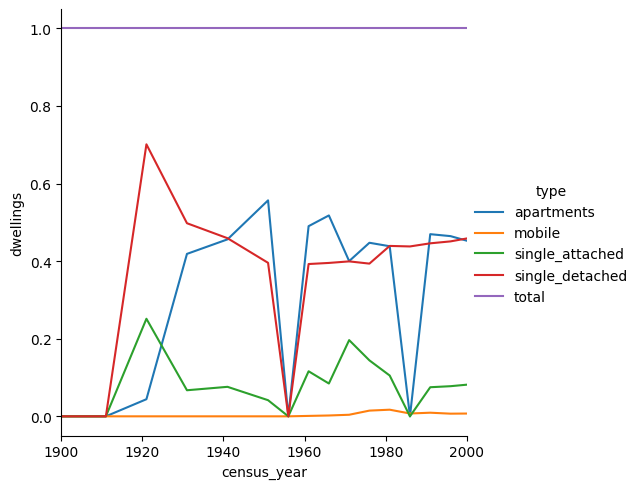

In [4]:
# Test for typesplit based on future interpolation
# This shows the typesplit before interpolation
tsplit = pd.DataFrame(
    df.groupby(by=["census_year", "type"])["dwellings"].max()
    / df.groupby(by=["census_year"])["dwellings"].first()
).reset_index()

g = sns.relplot(
    data=tsplit[
        tsplit["type"].isin(
            ["total", "single_detached", "single_attached", "apartments", "mobile"]
        )
    ],
    x="census_year",
    y="dwellings",
    hue="type",
    kind="line",
)
g.set(xlim=(1900, 2000))

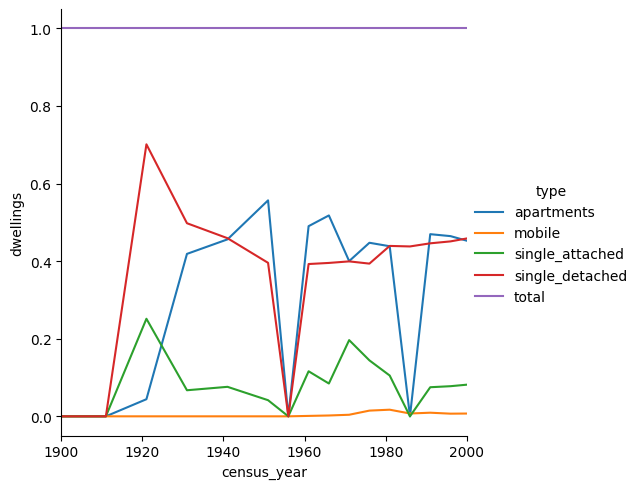

In [5]:
# new approach for tsplit
# Get number of dwellings per type, (total, i.e., 1608-2025) 
s = df[df['vintage']=='1608-2025'].groupby(by=["census_year", "type"])["dwellings"].sum()

shares = (s / s.xs('total', level='type')).reset_index()


g = sns.relplot(
    data=shares[shares['type'].isin(["total", "single_detached", "single_attached", "apartments", "mobile"])],
    x="census_year",
    y="dwellings",
    hue="type",
    kind="line",
)
g.set(xlim=(1900, 2000))

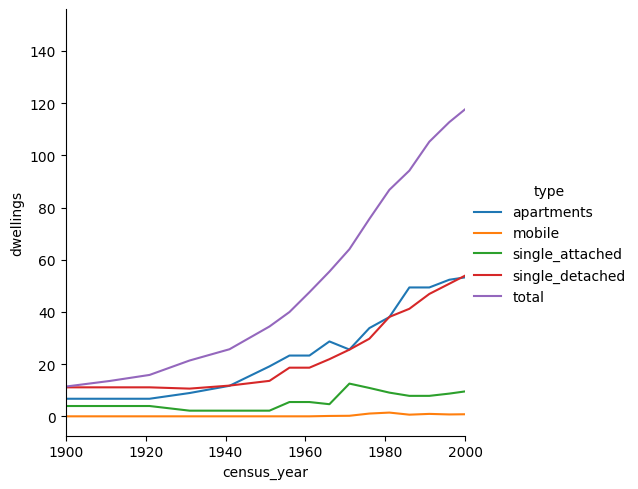

In [6]:
# Interpolation method #1
df2 = []
groups = df.groupby(by=["vintage", "type"])
for name, group in groups:
    group = group.bfill()
    df2.append(group)

df2 = pd.concat(df2)

tsplit2 = pd.DataFrame(
    df2.groupby(by=["census_year", "type"])["dwellings"].max()
    / df2.groupby(by=["census_year"])["dwellings"].first()
).reset_index()

g = sns.relplot(
    data=tsplit2[
        tsplit2["type"].isin(
            ["total", "single_detached", "single_attached", "apartments", "mobile"]
        )
    ],
    x="census_year",
    y="dwellings",
    hue="type",
    kind="line",
)
g.set(xlim=(1900, 2000))

of course, this doesn't work - we would at least need to do a IPFN pass to adjust weights before calculating typesplit, and even then, the weights would be wrong, since nothing guarantees that the data for different (types, cohorts) would come from the same year. So a 1981 apartment count could be pulled, and a 1921 mobile count, and then the IPFN would adjust weights based on this data. This would of course introduce wrong weights to older data.

In [7]:
# Test new approach
df.pivot(index="census_year", columns=["vintage", "type"])

dwellings                                                      \
vintage      1608-2025                                                       
type             total apartments   mobile single_attached single_detached   
census_year                                                                  
1685            1990.0        NaN      NaN             NaN             NaN   
1688            1877.0        NaN      NaN             NaN             NaN   
1692            1929.0        NaN      NaN             NaN             NaN   
1695            1934.0        NaN      NaN             NaN             NaN   
1698            2310.0        NaN      NaN             NaN             NaN   
1765           12230.0        NaN      NaN             NaN             NaN   
1784           18924.0        NaN      NaN             NaN             NaN   
1831           82437.0        NaN      NaN             NaN             NaN   
1844          108749.0        NaN      NaN             NaN             NaN   
1851          121961.0        NaN      NaN             NaN             NaN   
1861          155088.0        NaN      NaN             NaN             NaN   
1871          180115.0        NaN      NaN             NaN             NaN   
1881          216432.0        NaN      NaN             NaN             NaN   
1891          246644.0        NaN      NaN             NaN             NaN   
1901          291427.0        NaN      NaN             NaN             NaN   
1911          340196.0        NaN      NaN             NaN             NaN   
1921          398267.0    17565.0      NaN        100167.0        279252.0   
1931          536383.0   224601.0      NaN         36045.0        266994.0   
1941          644529.0   294024.0      NaN         49009.0        295930.0   
1951          862599.0   480215.0      NaN         35870.0        341310.0   
1956         1001264.0        NaN      NaN             NaN             NaN   
1961         1191368.0   583983.0   1296.0        138373.0        467716.0   
1966         1389115.0   719343.0   2989.0        117501.0        549282.0   
1971         1603685.0   641650.0   6490.0        315025.0        640520.0   
1976         1894111.0   847430.0  27885.0        273200.0        745595.0   
1981         2172860.0   952700.0  37155.0        228545.0        954455.0   
1986         2357105.0        NaN  17150.0             NaN       1032230.0   
1991         2634300.0  1236945.0  24605.0        197565.0       1174795.0   
1996         2822030.0  1310895.0  19350.0        219180.0       1272605.0   
2001         2978115.0  1339680.0  21645.0        245785.0       1371005.0   
2006         3189345.0  1461445.0  21545.0        247945.0       1458400.0   
2011         3395220.0  1535370.0  22875.0        276635.0       1560350.0   
2016         3531660.0  1606150.0  23295.0        299550.0       1602675.0   
2021         3749035.0  1738185.0  23640.0        315105.0       1672095.0   

                                                                           \
vintage                                                                     
type        other_dwelling apartment_duplex apartment_ge_5 apartment_lt_5   
census_year                                                                 
1685                   NaN              NaN            NaN            NaN   
1688                   NaN              NaN            NaN            NaN   
1692                   NaN              NaN            NaN            NaN   
1695                   NaN              NaN            NaN            NaN   
1698                   NaN              NaN            NaN            NaN   
1765                   NaN              NaN            NaN            NaN   
1784                   NaN              NaN            NaN            NaN   
1831                   NaN              NaN            NaN            NaN   
1844                   NaN              NaN            NaN            NaN   
1851                   NaN              NaN    

here, we can clearly see the issue, see the bfill() data that would be pulled, e.g., apartments (1921: 17565.0) and mobile (1961: 1296). This makes no sense. The process should be done census by census. this seems intuitively better, as the best 'guess' for a unknown census would be the 'next' census.

In [8]:
# check totals
initial_totals = df[df['type']=='total'].pivot(index="census_year", columns=["vintage", "type"])
# FIXME it could be that the interpolation (followed by fix marginals) is wrong due to not being linear/based on year, but based on *decade*
initial_totals

dwellings                                                    \
vintage      1608-2025 1608-1920 1921-1945 1946-1960 1961-1970 1971-1980   
type             total     total     total     total     total     total   
census_year                                                                
1685            1990.0    1990.0       0.0       0.0       0.0       0.0   
1688            1877.0    1877.0       0.0       0.0       0.0       0.0   
1692            1929.0    1929.0       0.0       0.0       0.0       0.0   
1695            1934.0    1934.0       0.0       0.0       0.0       0.0   
1698            2310.0    2310.0       0.0       0.0       0.0       0.0   
1765           12230.0   12230.0       0.0       0.0       0.0       0.0   
1784           18924.0   18924.0       0.0       0.0       0.0       0.0   
1831           82437.0   82437.0       0.0       0.0       0.0       0.0   
1844          108749.0  108749.0       0.0       0.0       0.0       0.0   
1851          121961.0  121961.0       0.0       0.0       0.0       0.0   
1861          155088.0  155088.0       0.0       0.0       0.0       0.0   
1871          180115.0  180115.0       0.0       0.0       0.0       0.0   
1881          216432.0  216432.0       0.0       0.0       0.0       0.0   
1891          246644.0  246644.0       0.0       0.0       0.0       0.0   
1901          291427.0  291427.0       0.0       0.0       0.0       0.0   
1911          340196.0  340196.0       0.0       0.0       0.0       0.0   
1921          398267.0       NaN       NaN       0.0       0.0       0.0   
1931          536383.0       NaN       NaN       0.0       0.0       0.0   
1941          644529.0       NaN       NaN       0.0       0.0       0.0   
1951          862599.0       NaN       NaN       NaN       0.0       0.0   
1956         1001264.0       NaN       NaN       NaN       0.0       0.0   
1961         1191368.0  357568.0  301937.0  517929.0   13934.0       0.0   
1966         1389115.0       NaN       NaN       NaN       NaN       0.0   
1971         1603685.0  316030.0  285630.0  543550.0  441645.0   16825.0   
1976         1894111.0       NaN       NaN       NaN       NaN       NaN   
1981         2172860.0  237670.0  295620.0  518040.0  480890.0  632060.0   
1986         2357105.0  223630.0  280685.0  506720.0  469880.0  647245.0   
1991         2634300.0  204285.0  270510.0  495950.0  498975.0  600180.0   
1996         2822030.0  200470.0  257735.0  522165.0  493595.0  604805.0   
2001         2978115.0  204125.0  246100.0  533870.0  505720.0  610275.0   
2006         3189345.0  210025.0  230575.0  538440.0  494995.0  610930.0   
2011         3395220.0  213270.0  215635.0  517985.0  507745.0  607710.0   
2016         3531660.0  204420.0  197305.0  492770.0  491450.0  625310.0   
2021         3749035.0  215130.0  191220.0  473025.0  490395.0  624300.0   

                                                                         \
vintage     1981-1990 1991-1995 1996-2000 2001-2005 2006-2010 2011-2015   
type            total     total     total     total     total     total   
census_year                                                               
1685              0.0       0.0       0.0       0.0       0.0       0.0   
1688              0.0       0.0       0.0       0.0       0.0       0.0   
1692              0.0       0.0       0.0       0.0       0.0       0.0   
1695              0.0       0.0       0.0       0.0       0.0       0.0   
1698              0.0       0.0       0.0       0.0       0.0       0.0   
1765              0.0       0.0       0.0       0.0       0.0       0.0   
1784              0.0       0.0       0.0       0.0       0.0       0.0   
1831              0.0       0.0       0.0       0.0       0.0       0.0   
1844              0.0       0.0       0.0       0.0       0.0       0.0   
1851              0.0       0.0       0.0       0.0       0.0       0.0   
1861              0.0       0.0       0.0       0.0       0.0       0.0   

In [ ]:
# Do it year by year, going backwards in time

# groups = df.groupby('census_year')
# for name, group in groups:
#     test=group.pivot(index=['census_year','vintage'],columns='type',values='dwellings')
#     display(test.head(2))

df3 = df.set_index(["census_year"]).sort_index(level=0, ascending=False).copy()
df3.index = df3.index.astype("int")
census_years =  df3.index.unique().to_list()
new_df = {}
for year in census_years:  # [:5]
    # Take individual census_year
    tsplit3 = df3.loc[year, :].pivot(
        index="vintage", columns="type", values="dwellings"
    )
    
    # Check if there are rows with nans to be bfilled()
    nan_rows = len(tsplit3[tsplit3.isna().any(axis=1)])
    if nan_rows:
        # if you must interpolate, take the data from new_data;
        # check what interpolation year to use; could be the last appended to new_data, but I think it might be better to check the actual year
        next_census = census_years[census_years.index(year) - 1]
        print(f"Census year '{year}': must interpolate from census '{next_census}'")
        # display(tsplit3)
       
        # retrieve dataframe of next census year; overwrite nans with values from the next census, keeping all values of the initial dataframe 
        tsplit3 = tsplit3.combine_first(new_df[next_census])
        # display(tsplit3)

        # NOTE this works decently well, however creates an issue when there are gaps of several Nans between censuses. only backfilling doesn't account for the two likely 'periods', i.e. growth (within span of vintage) followed by stability/decline (after cohort end)
        # FIXME a fix would need to split groups into two: for Nans (cs years) that fall within a cohort, interpolate linearly; for nans that fall after a cohort, interpolate backfill
    else:
        print(f"Census year '{year}': no need for interpolation")
    # TODO there won't ever be interpolation for the most recent year (here, 2021); treat explicitly as specific case? Or we could interpolate forward if there's no available bfill()

    # After interpolation, fix marginals
    new_data, diff = itp.reconcile_data_with_marginals(tsplit3)
    # new_data.stack().reset_index()  # FIXME to add year back?
    # new_data['census_year'] = year  # FIXME to add year back?
    new_df[year] = new_data
    # display(diff)  # can be useful for documentation; maybe check max/min value to see largest diff

    if nan_rows:
        # TODO log this in a notebook or html? see docs/nice_to_have.md
        print(f'result for year {year}:')
        # display(new_data.head(2))
        # display(diff)

res = pd.concat(new_df).stack('type').reset_index().rename(columns={"level_0":"census_year", 0:'dwellings'})
display(res)

==================== New run at 2025-10-22 11:19:05 ====================
==================== New run at 2025-10-22 11:19:05 ====================
==================== New run at 2025-10-22 11:19:05 ====================
Successfully loaded config from /home/cbreton/dev/cbreton026/uncertimety/data/config.toml
==================== New run at 2025-10-22 11:19:05 ====================
Successfully loaded config from /home/cbreton/dev/cbreton026/uncertimety/data/config.toml
Modified type marginals: 10.0 units ([5. 0. 1. 4.]) from {"apartments":1738185.0,"mobile":23640.0,"single_attached":315105.0,"single_detached":1672095.0}
Modified cohort marginals: -5.0 units ([ 0.  0. -1. -1. -1. -1.  0.  0.  0. -1.  0.  0.  0.]) from {"1608-1920":215130.0,"1921-1945":191220.0,"1946-1960":473025.0,"1961-1970":490395.0,"1971-1980":624300.0,"1981-1990":509125.0,"1991-1995":219080.0,"1996-2000":166240.0,"2001-2005":198590.0,"2006-2010":231935.0,"2011-2015":212285.0,"2016-2020":200968.0,"2021-2025":16747.0}
S

Census year '2021': no need for interpolation
type         total  apartments  mobile  single_attached  single_detached
vintage                                                                 
1608-1920   215130      108425     235            15700            90780
1608-2025  3749035     1738190   23640           315106          1672099
1921-1945   191220      113375     155            11755            65940
1946-1960   473024      244625     545            25510           202345
1961-1970   490394      262830    2160            22690           202695
1971-1980   624299      243705   10290            49315           320995
1981-1990   509124      210730    4105            46165           248120
1991-1995   219080       83955    1150            32085           101885
1996-2000   166240       66940     850            19605            78840
2001-2005   198590       75350     745            18005           104490
2006-2010   231934       96310    1030            27615           106985
2011-

Sum of IPFN adjustment difference: -10.02
Modified type marginals: 10.0 units ([5. 0. 1. 4.]) from {"apartments":1461445.0,"mobile":21545.0,"single_attached":247945.0,"single_detached":1458400.0}
Modified cohort marginals: 15.0 units ([1. 1. 3. 2. 3. 2. 1. 1. 1. 0.]) from {"1608-1920":210025.0,"1921-1945":230575.0,"1946-1960":538440.0,"1961-1970":494995.0,"1971-1980":610930.0,"1981-1990":532115.0,"1991-1995":213405.0,"1996-2000":142945.0,"2001-2005":199292.0,"2006-2010":16608.0}
Sum of IPFN adjustment difference: 10.0
Modified cohort marginals: 5.0 units ([0. 1. 1. 1. 1. 1. 0. 0. 0.]) from {"1608-1920":204125.0,"1921-1945":246100.0,"1946-1960":533870.0,"1961-1970":505720.0,"1971-1980":610275.0,"1981-1990":530580.0,"1991-1995":207945.0,"1996-2000":128765.0,"2001-2005":10730.0}
Sum of IPFN adjustment difference: -194621.99
Marginals fit; no modifications required.


Census year '2006': no need for interpolation
type           total  apartments   mobile  single_attached  single_detached
vintage                                                                    
1608-1920   210026.0     98660.0    310.0          15905.0          95160.0
1608-2025  3189345.0   1461450.0  21545.0         247946.0        1458404.0
1921-1945   230576.0    143240.0    290.0          13580.0          73465.0
1946-1960   538443.0    299060.0    790.0          27545.0         211040.0
1961-1970   494997.0    268650.0   1800.0          23155.0         201390.0
1971-1980   610933.0    226990.0  11215.0          48620.0         324100.0
1981-1990   532117.0    224440.0   4105.0          46985.0         256580.0
1991-1995   213406.0     74655.0   1290.0          32985.0         104480.0
1996-2000   142946.0     44410.0    760.0          19115.0          78660.0
2001-2005   199293.0     75079.0    914.0          18513.0         104792.0
2006-2010    16608.0      6256.0     76.0 

Sum of IPFN adjustment difference: -50406.0
Modified type marginals: 390.0 units ([183.   4.  29. 174.]) from {"apartments":1236945.0,"mobile":24605.0,"single_attached":197565.0,"single_detached":1174795.0}
Sum of IPFN adjustment difference: -90706.01
Modified type marginals: -126997.0 units ([-63247.   -877. -10102. -52771.]) from {"apartments":1237128.0,"mobile":17150.0,"single_attached":197594.0,"single_detached":1032230.0}
Modified cohort marginals: 175.0 units ([16. 21. 38. 35. 48. 17.]) from {"1608-1920":223630.0,"1921-1945":280685.0,"1946-1960":506720.0,"1961-1970":469880.0,"1971-1980":647245.0,"1981-1990":228770.0}
Sum of IPFN adjustment difference: -114677.0


...

Sum of IPFN adjustment difference: -13212.0
Modified type marginals: -26312.0 units ([ -1161.    -74.  -6620. -18457.]) from {"apartments":4798.0,"mobile":305.0,"single_attached":27363.0,"single_detached":76283.0}
Sum of IPFN adjustment difference: -26312.0
Modified type marginals: -63513.0 units ([ -2802.   -178. -15981. -44552.]) from {"apartments":3637.0,"mobile":231.0,"single_attached":20743.0,"single_detached":57826.0}
Sum of IPFN adjustment difference: -63513.0
Modified type marginals: -6694.0 units ([ -295.   -19. -1685. -4695.]) from {"apartments":835.0,"mobile":53.0,"single_attached":4762.0,"single_detached":13274.0}
Sum of IPFN adjustment difference: -6694.0
Modified type marginals: -9920.0 units ([ -438.   -27. -2496. -6959.]) from {"apartments":540.0,"mobile":34.0,"single_attached":3077.0,"single_detached":8579.0}
Sum of IPFN adjustment difference: -9920.0


result for year 1844:
Census year '1831': must interpolate from census '1844'
type         total  apartments  mobile  single_attached  single_detached
vintage                                                                 
1608-1920  82437.0      4798.0   305.0          27363.0          76283.0
1608-2025  82437.0      3637.0   231.0          20743.0          57826.0
result for year 1831:
Census year '1784': must interpolate from census '1831'
type         total  apartments  mobile  single_attached  single_detached
vintage                                                                 
1608-1920  18924.0      3637.0   231.0          20743.0          57826.0
1608-2025  18924.0       835.0    53.0           4762.0          13274.0
result for year 1784:
Census year '1765': must interpolate from census '1784'
type         total  apartments  mobile  single_attached  single_detached
vintage                                                                 
1608-1920  12230.0       835.0    53

Modified type marginals: -376.0 units ([ -17.   -1.  -94. -264.]) from {"apartments":102.0,"mobile":7.0,"single_attached":581.0,"single_detached":1620.0}
Sum of IPFN adjustment difference: -376.0
Modified type marginals: -5.0 units ([ 0.  0. -1. -4.]) from {"apartments":85.0,"mobile":6.0,"single_attached":487.0,"single_detached":1356.0}
Sum of IPFN adjustment difference: -5.0
Modified type marginals: -52.0 units ([ -2.   0. -13. -37.]) from {"apartments":85.0,"mobile":6.0,"single_attached":486.0,"single_detached":1352.0}
Sum of IPFN adjustment difference: -52.0
Modified type marginals: 113.0 units ([ 5.  0. 29. 79.]) from {"apartments":83.0,"mobile":6.0,"single_attached":473.0,"single_detached":1315.0}
Sum of IPFN adjustment difference: 113.0


Census year '1695': must interpolate from census '1698'
type        total  apartments  mobile  single_attached  single_detached
vintage                                                                
1608-1920  1934.0       102.0     7.0            581.0           1620.0
1608-2025  1934.0        85.0     6.0            487.0           1356.0
result for year 1695:
Census year '1692': must interpolate from census '1695'
type        total  apartments  mobile  single_attached  single_detached
vintage                                                                
1608-1920  1929.0        85.0     6.0            487.0           1356.0
1608-2025  1929.0        85.0     6.0            486.0           1352.0
result for year 1692:
Census year '1688': must interpolate from census '1692'
type        total  apartments  mobile  single_attached  single_detached
vintage                                                                
1608-1920  1877.0        85.0     6.0            486.0           135

,census_year,vintage,type,dwellings
0,2021,1608-1920,total,215130
1,2021,1608-1920,apartments,108419
2,2021,1608-1920,mobile,235
3,2021,1608-1920,single_attached,15700
4,2021,1608-1920,single_detached,90776
...,...,...,...,...
2375,1685,2021-2025,total,0
2376,1685,2021-2025,apartments,0
2377,1685,2021-2025,mobile,0
2378,1685,2021-2025,single_attached,0


In [10]:
initial_totals

dwellings                                                    \
vintage      1608-2025 1608-1920 1921-1945 1946-1960 1961-1970 1971-1980   
type             total     total     total     total     total     total   
census_year                                                                
1685            1990.0    1990.0       0.0       0.0       0.0       0.0   
1688            1877.0    1877.0       0.0       0.0       0.0       0.0   
1692            1929.0    1929.0       0.0       0.0       0.0       0.0   
1695            1934.0    1934.0       0.0       0.0       0.0       0.0   
1698            2310.0    2310.0       0.0       0.0       0.0       0.0   
1765           12230.0   12230.0       0.0       0.0       0.0       0.0   
1784           18924.0   18924.0       0.0       0.0       0.0       0.0   
1831           82437.0   82437.0       0.0       0.0       0.0       0.0   
1844          108749.0  108749.0       0.0       0.0       0.0       0.0   
1851          121961.0  121961.0       0.0       0.0       0.0       0.0   
1861          155088.0  155088.0       0.0       0.0       0.0       0.0   
1871          180115.0  180115.0       0.0       0.0       0.0       0.0   
1881          216432.0  216432.0       0.0       0.0       0.0       0.0   
1891          246644.0  246644.0       0.0       0.0       0.0       0.0   
1901          291427.0  291427.0       0.0       0.0       0.0       0.0   
1911          340196.0  340196.0       0.0       0.0       0.0       0.0   
1921          398267.0       NaN       NaN       0.0       0.0       0.0   
1931          536383.0       NaN       NaN       0.0       0.0       0.0   
1941          644529.0       NaN       NaN       0.0       0.0       0.0   
1951          862599.0       NaN       NaN       NaN       0.0       0.0   
1956         1001264.0       NaN       NaN       NaN       0.0       0.0   
1961         1191368.0  357568.0  301937.0  517929.0   13934.0       0.0   
1966         1389115.0       NaN       NaN       NaN       NaN       0.0   
1971         1603685.0  316030.0  285630.0  543550.0  441645.0   16825.0   
1976         1894111.0       NaN       NaN       NaN       NaN       NaN   
1981         2172860.0  237670.0  295620.0  518040.0  480890.0  632060.0   
1986         2357105.0  223630.0  280685.0  506720.0  469880.0  647245.0   
1991         2634300.0  204285.0  270510.0  495950.0  498975.0  600180.0   
1996         2822030.0  200470.0  257735.0  522165.0  493595.0  604805.0   
2001         2978115.0  204125.0  246100.0  533870.0  505720.0  610275.0   
2006         3189345.0  210025.0  230575.0  538440.0  494995.0  610930.0   
2011         3395220.0  213270.0  215635.0  517985.0  507745.0  607710.0   
2016         3531660.0  204420.0  197305.0  492770.0  491450.0  625310.0   
2021         3749035.0  215130.0  191220.0  473025.0  490395.0  624300.0   

                                                                         \
vintage     1981-1990 1991-1995 1996-2000 2001-2005 2006-2010 2011-2015   
type            total     total     total     total     total     total   
census_year                                                               
1685              0.0       0.0       0.0       0.0       0.0       0.0   
1688              0.0       0.0       0.0       0.0       0.0       0.0   
1692              0.0       0.0       0.0       0.0       0.0       0.0   
1695              0.0       0.0       0.0       0.0       0.0       0.0   
1698              0.0       0.0       0.0       0.0       0.0       0.0   
1765              0.0       0.0       0.0       0.0       0.0       0.0   
1784              0.0       0.0       0.0       0.0       0.0       0.0   
1831              0.0       0.0       0.0       0.0       0.0       0.0   
1844              0.0       0.0       0.0       0.0       0.0       0.0   
1851              0.0       0.0       0.0       0.0       0.0       0.0   
1861              0.0       0.0       0.0       0.0       0.0       0.0   

<Axes: xlabel='census_year'>

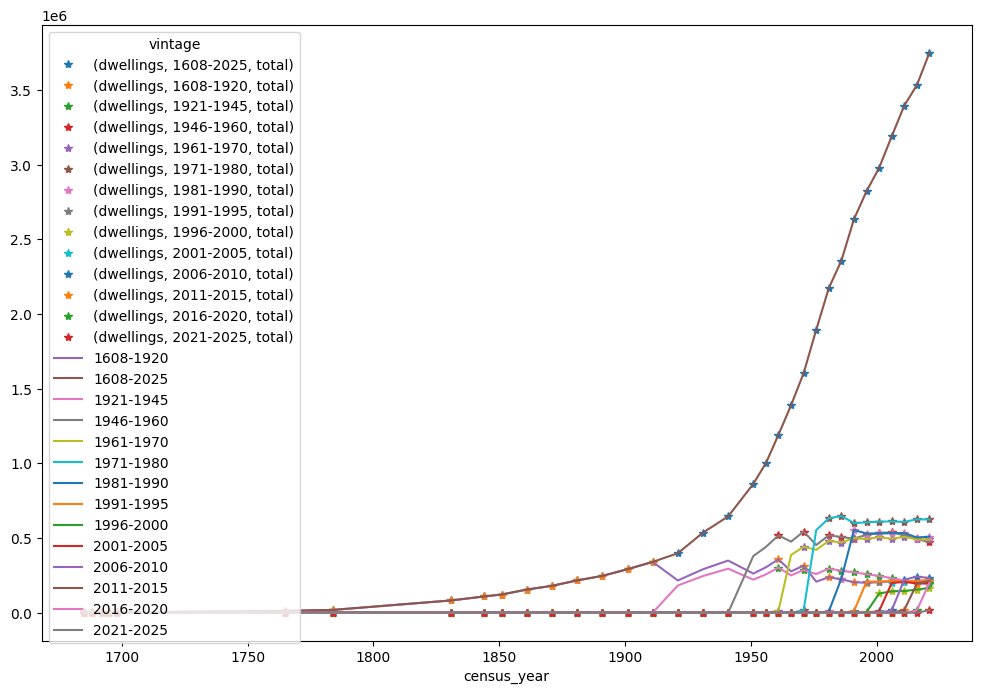

In [11]:
# TODO Quickcheck: plot totals before and after interpolation
fig, axs = plt.subplots(figsize=(12,8))
# axs=axs.ravel()

initial_totals.plot(style='*', ax=axs)
res[res['type']=='total'].pivot(index='census_year', columns='vintage', values='dwellings').plot(style='-', ax=axs)

the result (line) seems to fit pretty close to the data points; however, one issue seems to be 'start' year for some interpolations, e.g., 180k+ dwellings form cohort 1921-1945 in.. 1921 - that's waaay too high.

Mostly, 1921-1945 and 1946-1960 seem at fault - for the other vintages, the first year of each vintage looks good (~10k). 1608-1920 also present 'squiggly' lines. No doubt this is due to long lines of Nans in the initial data.

FIXME
- maybe let it as is, then smooth the data?
- maybe attempt to fix initial problem, especially the high early counts (e.g., 1921-1945)

     census_year             type  dwellings
0           1685       apartments   0.044221
1           1685           mobile   0.003015
2           1685  single_attached   0.252261
3           1685  single_detached   0.700503
4           1685            total   1.000000
..           ...              ...        ...
165         2021       apartments   0.463637
166         2021           mobile   0.006306
167         2021  single_attached   0.084050
168         2021  single_detached   0.446008
169         2021            total   1.000000

[170 rows x 3 columns]


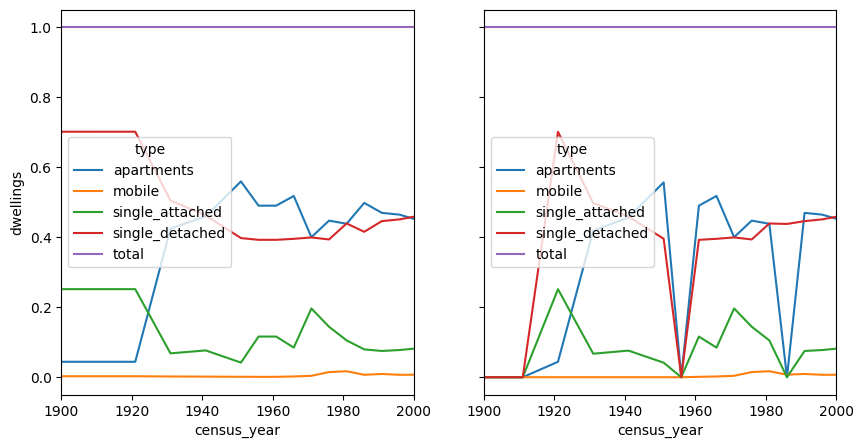

In [12]:
# Test for typesplit based on future interpolation
# Group by census_year and type and sum the dwellings
s = res[res['vintage'] == '1608-2025'].groupby(['census_year', 'type'])['dwellings'].sum()

# For each census_year, divide by the total value
shares = (s / s.xs('total', level='type')).reset_index()
print(shares)

# NOTE Alternate method
# df_pivot = res[res['vintage'] == '1608-2025'].pivot_table(
#     index='census_year',
#     columns='type',
#     values='dwellings',
#     aggfunc='sum'
# )
# shares_df = df_pivot.div(df_pivot['total'], axis=0)
# print(shares_df)

# This shows the typesplit after interpolation
fig, axs = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True)
axs=axs.ravel()

sns.lineplot(
    data=shares,
    x="census_year",
    y="dwellings",
    hue="type",
    ax=axs[0],
    # kind="line",
)

sns.lineplot(
    data=tsplit[
        tsplit["type"].isin(
            ["total", "single_detached", "single_attached", "apartments", "mobile"]
        )
    ],
    x="census_year",
    y="dwellings",
    hue="type",
    ax=axs[1],

    # kind="line",
)

for ax in axs:
    ax.set_xlim(1900, 2000)


NOTE: This seems pretty decent. However, there remains the question of what to do with single attached / apartments before 1921 - was it a 'good' year to learn from (i.e., to propagate backwards using bfill)?

In [13]:
# Attempt full plot by vintage
dfx = res.groupby(['census_year', 'type','vintage']).sum()  # full values per year, census_year and type

dfx['share'] = dfx.groupby(level=[0, 2])["dwellings"].transform(
    lambda x: x / x.loc[x.index.get_level_values(1) == "total"].iloc[0]
)
dfx = dfx.reset_index()
dfx

,census_year,type,vintage,dwellings,share
0,1685,apartments,1608-1920,88,0.044221
1,1685,apartments,1608-2025,88,0.044221
2,1685,apartments,1921-1945,0,NaN
3,1685,apartments,1946-1960,0,NaN
4,1685,apartments,1961-1970,0,NaN
...,...,...,...,...,...
2375,2021,total,2001-2005,198590,1.000000
2376,2021,total,2006-2010,231934,1.000000
2377,2021,total,2011-2015,212285,1.000000
2378,2021,total,2016-2020,200968,1.000000


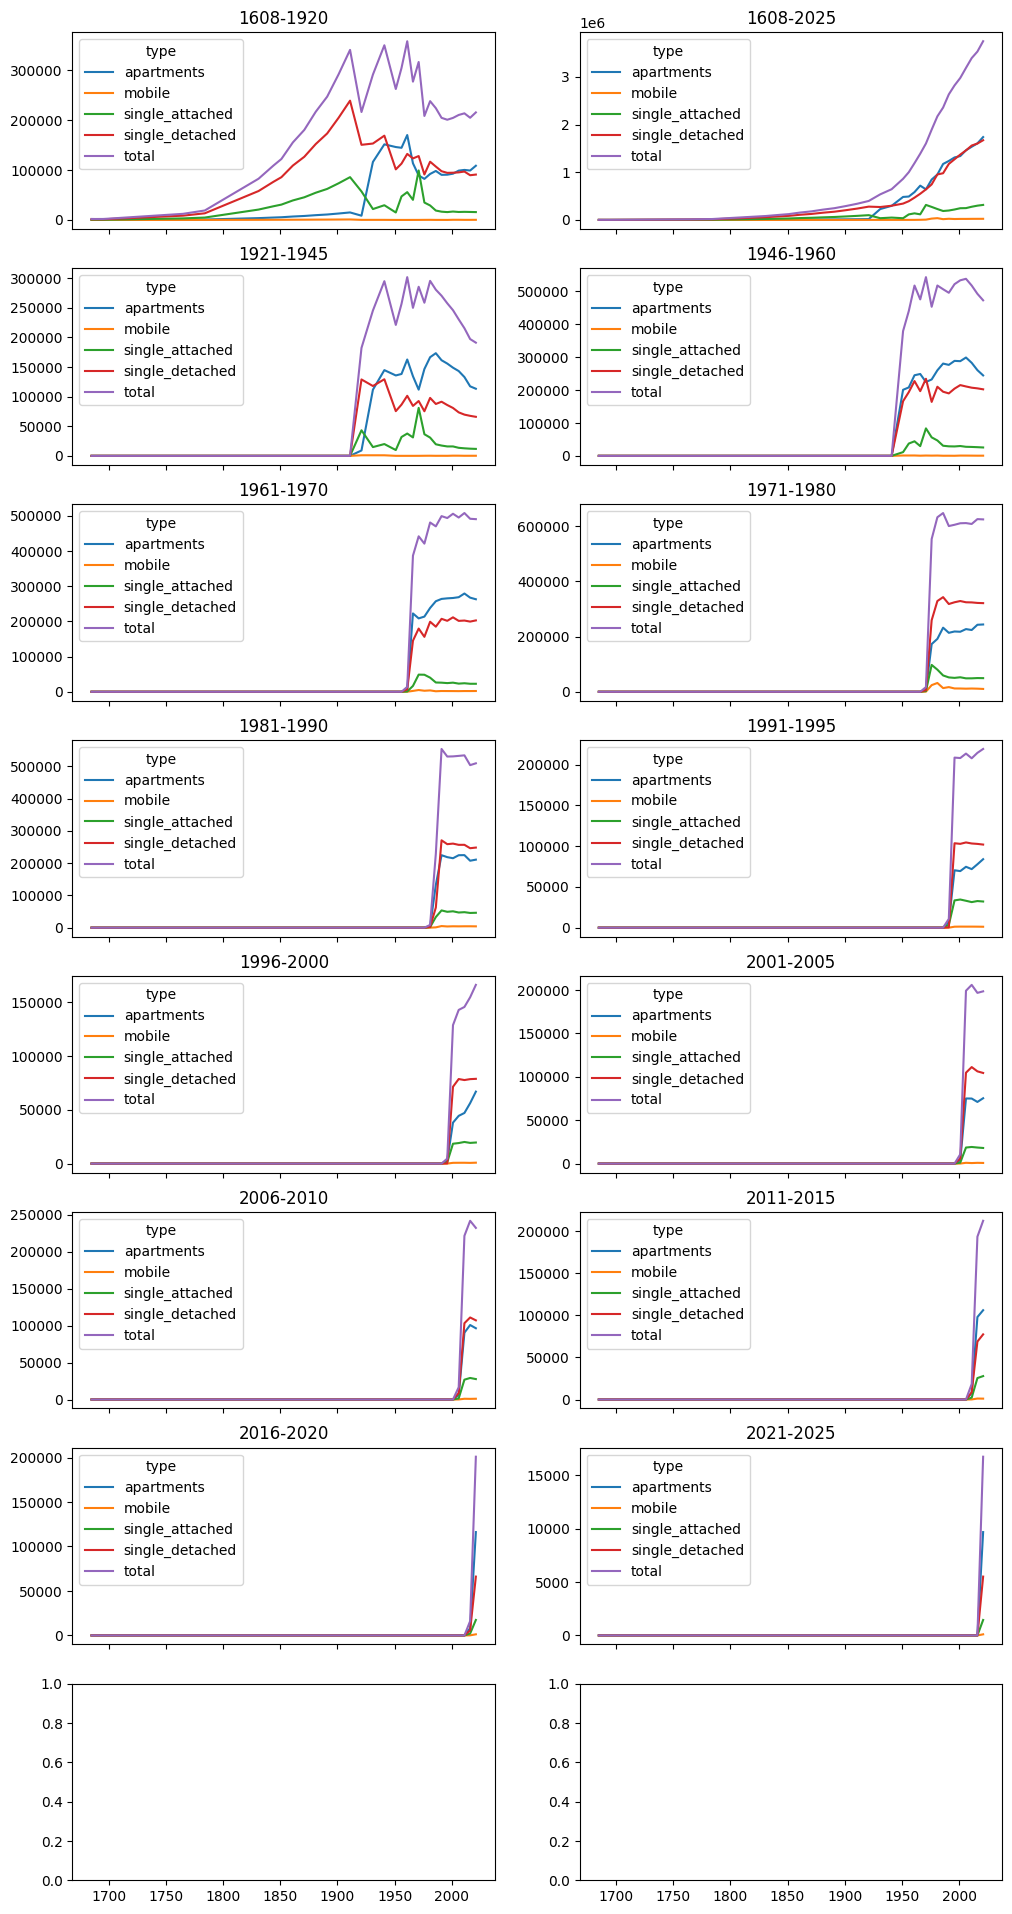

In [14]:
agg_types = [
    "total",
    "single_detached",
    "single_attached",
    "apartments",
    "mobile",
    # "other_dwelling",
]

n_vintages = len(dfx["vintage"].unique())
fig, ax = plt.subplots(
    (n_vintages // 2) + 1,
    2,
    figsize=(12, 3 * ((n_vintages // 2) + 1)),
    sharex=True,
    sharey=False,
)
ax = ax.ravel()

for i, vintage in enumerate(dfx["vintage"].unique()):
    tempdata = dfx[
        (dfx["vintage"] == vintage) & (dfx["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    # display(tempdata)
    tempdata.plot(ax=ax[i])
    ax[i].set_title(vintage)

In [15]:
# FIXME - Seems wrong that the 'total' go up and down so much? Why? it could be because the later years are not necessarily 'good', and thus using bfill would 'contradict' earlier counts. However, it more likely is that 'older' counts were not so good, and backfilling introduces contradictions?
# Or it could be an artifact of the IPFN method?
# Mybe try to fix by looking at previous AND following year, and use min? OR, use some kind of smoothing?

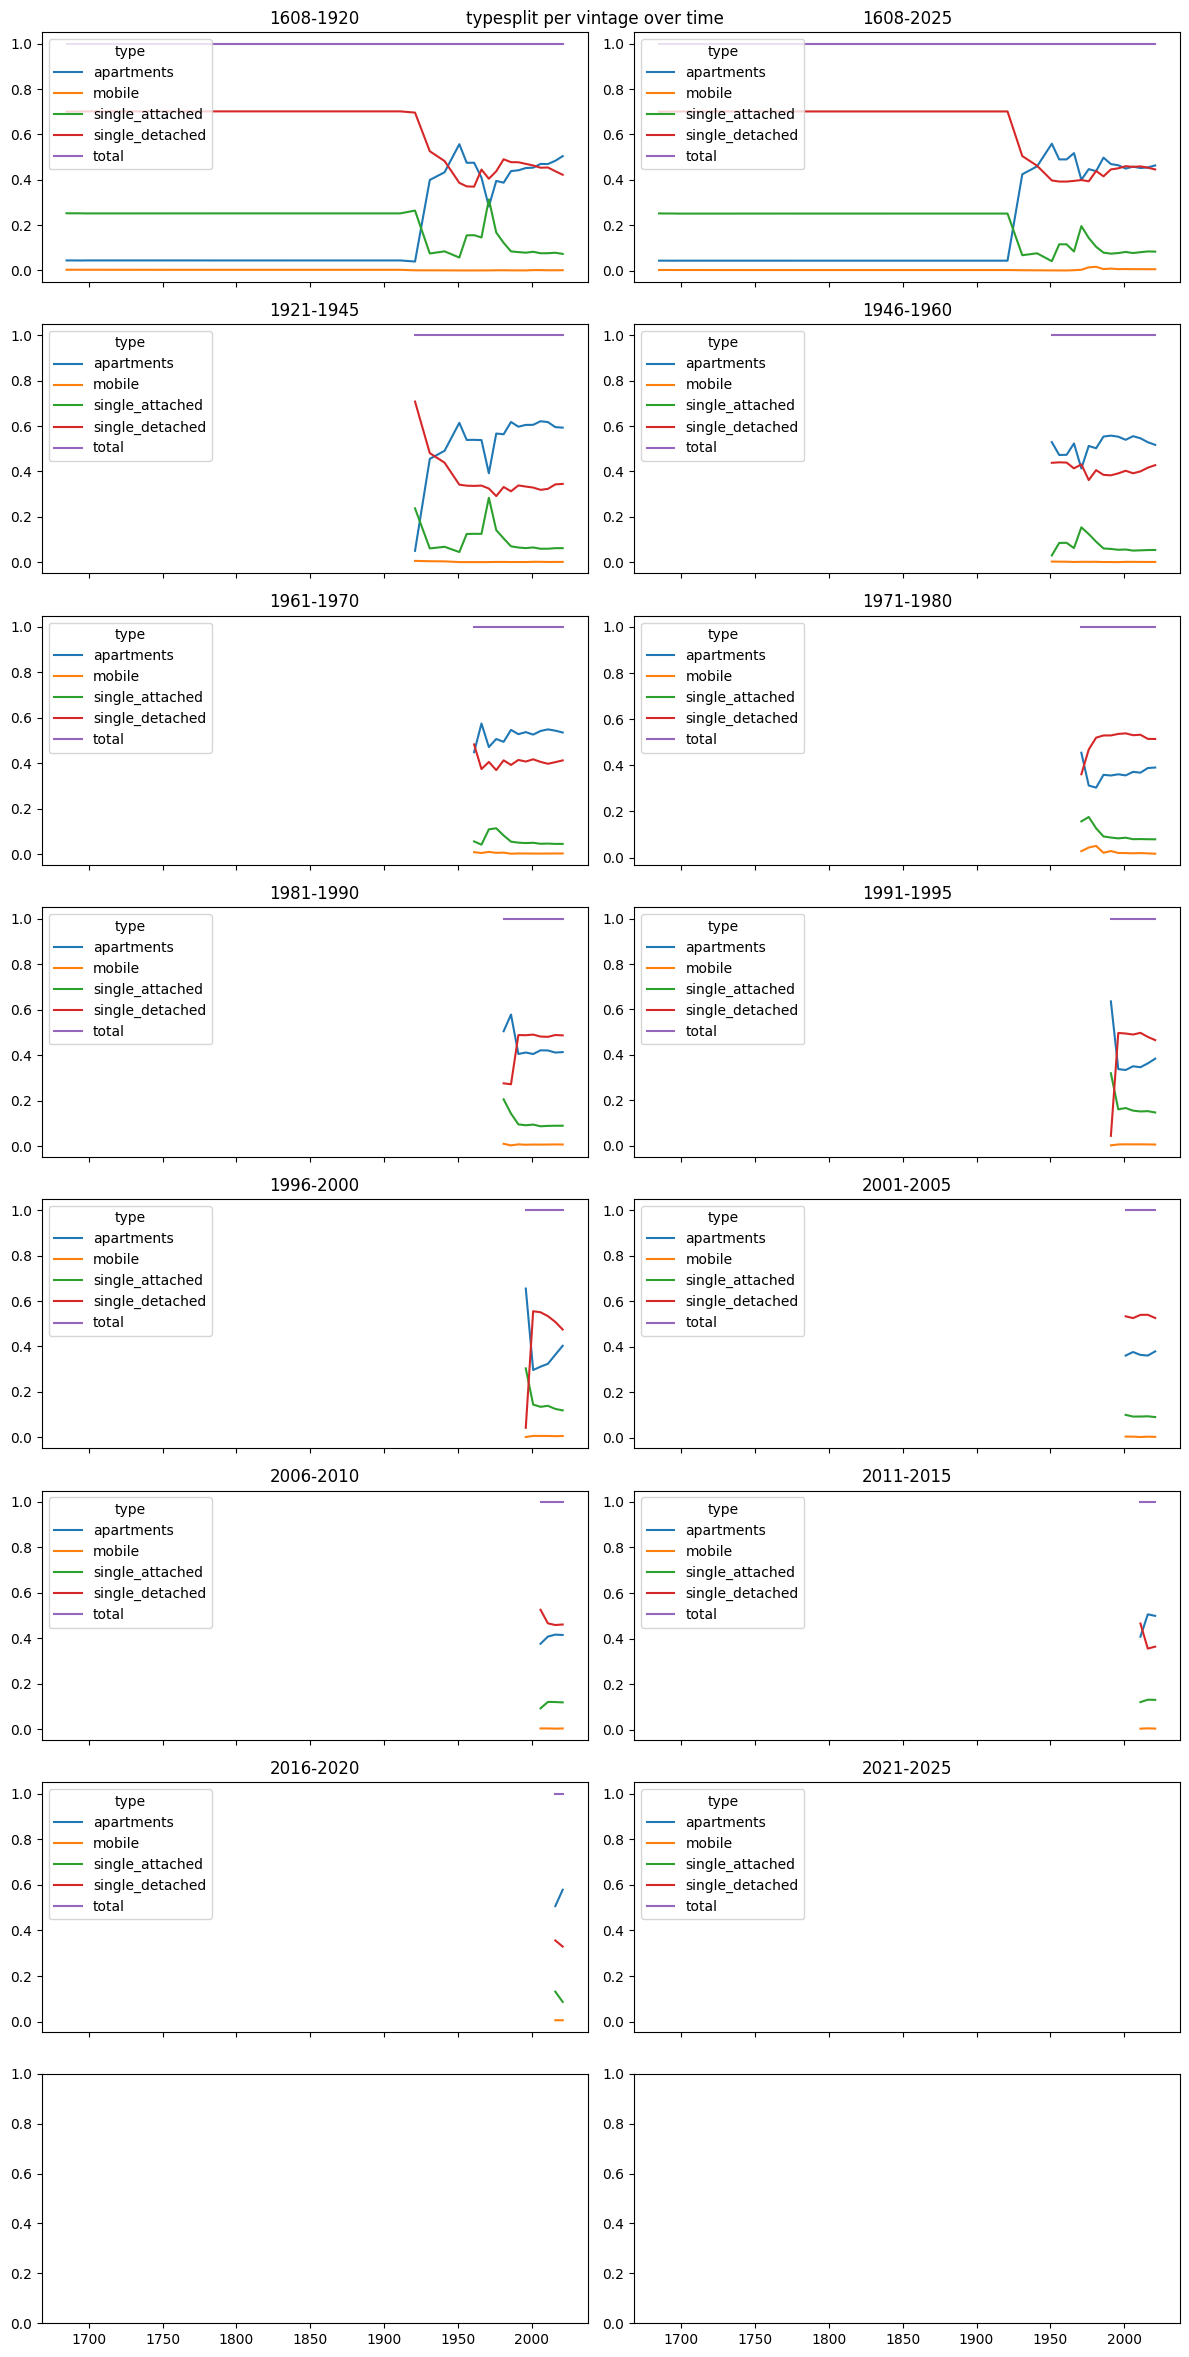

In [16]:
fig, ax = plt.subplots(
    (n_vintages // 2) + 1,
    2,
    figsize=(12, 3 * ((n_vintages // 2) + 1)),
    sharex=True,
    sharey=False,
)
ax = ax.ravel()

for i, vintage in enumerate(dfx["vintage"].unique()):
    dfx[
        (dfx["vintage"] == vintage) & (dfx["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="share").plot(ax=ax[i])
    ax[i].set_title(vintage)

fig.suptitle('typesplit per vintage over time')
plt.tight_layout()

It seems like these should be pretty stable over time? If not, it might imply that there were conversions (?)

##  new attempt for interpolation

In [17]:
initial_totals

dwellings                                                    \
vintage      1608-2025 1608-1920 1921-1945 1946-1960 1961-1970 1971-1980   
type             total     total     total     total     total     total   
census_year                                                                
1685            1990.0    1990.0       0.0       0.0       0.0       0.0   
1688            1877.0    1877.0       0.0       0.0       0.0       0.0   
1692            1929.0    1929.0       0.0       0.0       0.0       0.0   
1695            1934.0    1934.0       0.0       0.0       0.0       0.0   
1698            2310.0    2310.0       0.0       0.0       0.0       0.0   
1765           12230.0   12230.0       0.0       0.0       0.0       0.0   
1784           18924.0   18924.0       0.0       0.0       0.0       0.0   
1831           82437.0   82437.0       0.0       0.0       0.0       0.0   
1844          108749.0  108749.0       0.0       0.0       0.0       0.0   
1851          121961.0  121961.0       0.0       0.0       0.0       0.0   
1861          155088.0  155088.0       0.0       0.0       0.0       0.0   
1871          180115.0  180115.0       0.0       0.0       0.0       0.0   
1881          216432.0  216432.0       0.0       0.0       0.0       0.0   
1891          246644.0  246644.0       0.0       0.0       0.0       0.0   
1901          291427.0  291427.0       0.0       0.0       0.0       0.0   
1911          340196.0  340196.0       0.0       0.0       0.0       0.0   
1921          398267.0       NaN       NaN       0.0       0.0       0.0   
1931          536383.0       NaN       NaN       0.0       0.0       0.0   
1941          644529.0       NaN       NaN       0.0       0.0       0.0   
1951          862599.0       NaN       NaN       NaN       0.0       0.0   
1956         1001264.0       NaN       NaN       NaN       0.0       0.0   
1961         1191368.0  357568.0  301937.0  517929.0   13934.0       0.0   
1966         1389115.0       NaN       NaN       NaN       NaN       0.0   
1971         1603685.0  316030.0  285630.0  543550.0  441645.0   16825.0   
1976         1894111.0       NaN       NaN       NaN       NaN       NaN   
1981         2172860.0  237670.0  295620.0  518040.0  480890.0  632060.0   
1986         2357105.0  223630.0  280685.0  506720.0  469880.0  647245.0   
1991         2634300.0  204285.0  270510.0  495950.0  498975.0  600180.0   
1996         2822030.0  200470.0  257735.0  522165.0  493595.0  604805.0   
2001         2978115.0  204125.0  246100.0  533870.0  505720.0  610275.0   
2006         3189345.0  210025.0  230575.0  538440.0  494995.0  610930.0   
2011         3395220.0  213270.0  215635.0  517985.0  507745.0  607710.0   
2016         3531660.0  204420.0  197305.0  492770.0  491450.0  625310.0   
2021         3749035.0  215130.0  191220.0  473025.0  490395.0  624300.0   

                                                                         \
vintage     1981-1990 1991-1995 1996-2000 2001-2005 2006-2010 2011-2015   
type            total     total     total     total     total     total   
census_year                                                               
1685              0.0       0.0       0.0       0.0       0.0       0.0   
1688              0.0       0.0       0.0       0.0       0.0       0.0   
1692              0.0       0.0       0.0       0.0       0.0       0.0   
1695              0.0       0.0       0.0       0.0       0.0       0.0   
1698              0.0       0.0       0.0       0.0       0.0       0.0   
1765              0.0       0.0       0.0       0.0       0.0       0.0   
1784              0.0       0.0       0.0       0.0       0.0       0.0   
1831              0.0       0.0       0.0       0.0       0.0       0.0   
1844              0.0       0.0       0.0       0.0       0.0       0.0   
1851              0.0       0.0       0.0       0.0       0.0       0.0   
1861              0.0       0.0       0.0       0.0       0.0       0.0   

In [18]:
# Use a combined approach - first backfill years outside cohort; then interpolate within cohort, knowing that there must be zero before cohort start
combined_method = []
groups = df3.reset_index().sort_values('census_year').copy().groupby(by=['vintage','type',])
for name, group in list(groups):
    vintage_start, vintage_end = [int(yr) for yr in name[0].split('-')]
    temp_df = group.copy()

    # First, backfill for stable/declining stocks
    mask = temp_df['census_year'].gt(vintage_end)
    temp_df[mask] = temp_df[mask].bfill()

    # Second, assume linear growth over the census period
    # NOTE: what to do with vintage 1608-1920? for several types, there is basically no data from 1685-1921. It *could* have grown, then shrunk. Here, I'll simply assume a linear growth over the full period, which will then get corrected when applying IPFN. Other methods could also be possible. FIXME: 1608-1920 might need another approach---following the growth curve of 'total' values? this might be naturally fixed by the IPFN later
    threshold = 10
    # mask = temp_df['census_year'].between(vintage_start, vintage_end + threshold, inclusive='both')

    # Do the linear interpolation
    temp = temp_df.copy().set_index('census_year')
    temp = temp.reindex(range(vintage_start - 1, vintage_end + 2))  # include year before and after (e.g., 1607-1921 for 1608-1920)
    temp.loc[vintage_start - 1, 'dwellings'] = 0
    temp['dwellings'] = temp['dwellings'].interpolate(method='index')
    temp['vintage'] = name[0]
    temp['type'] = name[1]

    # Fix indexes
    temp_df = temp_df.set_index(['census_year'])
    temp = temp.reindex(temp_df.index)

    temp_df = temp_df.combine_first(temp).reset_index()
    # display(temp)
    # display(temp_df)

    # retrieve results
    combined_method.append(temp_df)

# THEN, after the interpolation, fix the marginals
combined_method = pd.concat(combined_method)
# (cont'd)

# NOTE on iterpolation. Over these long periods, I know *nothing* of outflows---use ODYM directly? ACTUALLY, this is completely artificial- IF I 'FORCE' stock levels in this way, am I not 'forcing' inflows and 'outflows'? Why am I doing this-- just to compare with the results of ODYM, which relies on population, lifetime, and typesplit? Is this just for comparison? This is mostly a concern for the 1608-1920, which definitely includes outflows. For shorter cohorts,  this might not be such an issue. FIXME -- maybe need to show the difference between 'real' initial data, 'fixed' (interpolated, ipfn) data, and ODYM results?

In [ ]:
# Fix the marginals and run IPFN
combined_df = {}
for year in census_years:
    print(f" === Census {year} === ")
    # Take individual census_year
    tsplit4 = combined_method.set_index('census_year').loc[year, :].pivot(
        index="vintage", columns="type", values="dwellings"
    )
    # display(tsplit4)
    new_data, diff = itp.reconcile_data_with_marginals(tsplit4)
    # new_data.stack().reset_index()  # FIXME to add year back?
    # new_data['census_year'] = year  # FIXME to add year back?
    combined_df[year] = new_data
    # display(diff)  # can be useful for documentation; maybe check max/min value to see largest diff

c_res = pd.concat(combined_df).stack('type').reset_index().rename(columns={"level_0":"census_year", 0:'dwellings'})
display(c_res)


Modified type marginals: 10.0 units ([5. 0. 1. 4.]) from {"apartments":1738185.0,"mobile":23640.0,"single_attached":315105.0,"single_detached":1672095.0}
Modified cohort marginals: -5.0 units ([ 0.  0. -1. -1. -1. -1.  0.  0.  0. -1.  0.  0.  0.]) from {"1608-1920":215130.0,"1921-1945":191220.0,"1946-1960":473025.0,"1961-1970":490395.0,"1971-1980":624300.0,"1981-1990":509125.0,"1991-1995":219080.0,"1996-2000":166240.0,"2001-2005":198590.0,"2006-2010":231935.0,"2011-2015":212285.0,"2016-2020":200968.0,"2021-2025":16747.0}
Sum of IPFN adjustment difference: 10.02
Modified type marginals: -10.0 units ([-5.  0. -1. -4.]) from {"apartments":1606150.0,"mobile":23295.0,"single_attached":299550.0,"single_detached":1602675.0}
Modified cohort marginals: -5.0 units ([ 0.  0. -1. -1. -1. -1.  0.  0.  0. -1.  0.  0.]) from {"1608-1920":204420.0,"1921-1945":197305.0,"1946-1960":492770.0,"1961-1970":491450.0,"1971-1980":625310.0,"1981-1990":503495.0,"1991-1995":214310.0,"1996-2000":154710.0,"2001-200

 === Census 2021 === 
type         total  apartments  mobile  single_attached  single_detached
vintage                                                                 
1608-1920   215130      108425     235            15700            90780
1608-2025  3749035     1738190   23640           315106          1672099
1921-1945   191220      113375     155            11755            65940
1946-1960   473024      244625     545            25510           202345
1961-1970   490394      262830    2160            22690           202695
1971-1980   624299      243705   10290            49315           320995
1981-1990   509124      210730    4105            46165           248120
1991-1995   219080       83955    1150            32085           101885
1996-2000   166240       66940     850            19605            78840
2001-2005   198590       75350     745            18005           104490
2006-2010   231934       96310    1030            27615           106985
2011-2015   212285      10607

Sum of IPFN adjustment difference: 10.0
Modified cohort marginals: 5.0 units ([0. 1. 1. 1. 1. 1. 0. 0. 0.]) from {"1608-1920":204125.0,"1921-1945":246100.0,"1946-1960":533870.0,"1961-1970":505720.0,"1971-1980":610275.0,"1981-1990":530580.0,"1991-1995":207945.0,"1996-2000":128765.0,"2001-2005":10730.0}
Sum of IPFN adjustment difference: -28529.99
Marginals fit; no modifications required.
Sum of IPFN adjustment difference: -24945.99
Modified type marginals: 390.0 units ([183.   4.  29. 174.]) from {"apartments":1236945.0,"mobile":24605.0,"single_attached":197565.0,"single_detached":1174795.0}
Sum of IPFN adjustment difference: -19879.02
Modified type marginals: -152.5 units ([-70.5  -1.  -14.  -67. ]) from {"apartments":1094822.5,"mobile":17150.0,"single_attached":213055.0,"single_detached":1032230.0}
Modified cohort marginals: 175.0 units ([16. 21. 38. 35. 48. 17.]) from {"1608-1920":223630.0,"1921-1945":280685.0,"1946-1960":506720.0,"1961-1970":469880.0,"1971-1980":647245.0,"1981-1990"

type           total  apartments   mobile  single_attached  single_detached
vintage                                                                    
1608-1920   210026.0     98660.0    310.0          15905.0          95160.0
1608-2025  3189345.0   1461450.0  21545.0         247946.0        1458404.0
1921-1945   230576.0    143240.0    290.0          13580.0          73465.0
1946-1960   538443.0    299060.0    790.0          27545.0         211040.0
1961-1970   494997.0    268650.0   1800.0          23155.0         201390.0
1971-1980   610933.0    226990.0  11215.0          48620.0         324100.0
1981-1990   532117.0    224440.0   4105.0          46985.0         256580.0
1991-1995   213406.0     74655.0   1290.0          32985.0         104480.0
1996-2000   142946.0     44410.0    760.0          19115.0          78660.0
2001-2005   199293.0     75079.0    914.0          18513.0         104792.0
2006-2010    16608.0      6256.0     76.0           1542.0           8733.0
 === Census 

Sum of IPFN adjustment difference: 29358.0
Modified type marginals: 1.0 units ([1. 0. 0. 0.]) from {"apartments":847430.0,"mobile":27885.0,"single_attached":273200.0,"single_detached":745595.0}
Modified cohort marginals: 37448.5 units ([ 4794.   5963.  10449.   9699.   6543.5]) from {"1608-1920":237670.0,"1921-1945":295620.0,"1946-1960":518040.0,"1961-1970":480890.0,"1971-1980":324442.5}
Sum of IPFN adjustment difference: 95262.01
Modified cohort marginals: 5.0 units ([1. 1. 2. 1. 0.]) from {"1608-1920":316030.0,"1921-1945":285630.0,"1946-1960":543550.0,"1961-1970":441645.0,"1971-1980":16825.0}
Sum of IPFN adjustment difference: 5.01
Modified cohort marginals: 16115.5 units ([3709.  3353.  6380.  2673.5]) from {"1608-1920":316030.0,"1921-1945":285630.0,"1946-1960":543550.0,"1961-1970":227789.5}
Sum of IPFN adjustment difference: 16115.99
Marginals fit; no modifications required.
Sum of IPFN adjustment difference: -0.01
Modified type marginals: -23747.194915254237 units ([-12327.       

...

Sum of IPFN adjustment difference: -134153.0
Modified type marginals: -187416.67030119832 units ([  -8268.23566879    -541.28813559  -47152.77707006 -131454.36942675]) from {"apartments":13649.2356687898,"mobile":893.2881355932,"single_attached":77836.7770700637,"single_detached":216998.3694267516}
Sum of IPFN adjustment difference: -155892.0
Modified type marginals: -191753.08139911477 units ([  -8459.65923567    -553.66101695  -48243.75477707 -134496.00636943]) from {"apartments":13257.6592356688,"mobile":867.6610169492,"single_attached":75603.7547770701,"single_detached":210773.0063694268}
Sum of IPFN adjustment difference: -161133.0
Modified type marginals: -201581.84486667387 units ([  -8893.44585987    -582.06779661  -50716.7133758  -141389.61783439]) from {"apartments":12530.4458598726,"mobile":820.0677966102,"single_attached":71456.7133757962,"single_detached":199211.6178343949}
Sum of IPFN adjustment difference: -172641.0
Modified type marginals: -205501.6050955414 units ([  -

 === Census 1851 === 
type          total  apartments  mobile  single_attached  single_detached
vintage                                                                  
1608-1920  121961.0    131978.0     3.0          43221.0         102651.0
1608-2025  121961.0      5381.0   352.0          30684.0          85544.0
 === Census 1844 === 
type          total  apartments  mobile  single_attached  single_detached
vintage                                                                  
1608-1920  108749.0    128192.0     3.0          41981.0          99706.0
1608-2025  108749.0      4798.0   314.0          27360.0          76277.0
 === Census 1831 === 
type         total  apartments  mobile  single_attached  single_detached
vintage                                                                 
1608-1920  82437.0    121160.0     3.0          39678.0          94237.0
1608-2025  82437.0      3637.0   238.0          20740.0          57822.0
 === Census 1784 === 
type         total  apartmen

Modified type marginals: -113072.65572708627 units ([ -4988.49363057   -326.15254237 -28448.28980892 -79309.71974522]) from {"apartments":5090.4936305732,"mobile":333.1525423729,"single_attached":29029.2898089172,"single_detached":80929.7197452229}
Sum of IPFN adjustment difference: -101315.0
Modified type marginals: -109644.83191190759 units ([ -4837.67515924   -316.16949153 -27585.28025478 -76905.70700637]) from {"apartments":4922.6751592357,"mobile":322.1694915254,"single_attached":28072.2802547771,"single_detached":78261.7070063694}
Sum of IPFN adjustment difference: -98274.0
Modified type marginals: -105846.00809672891 units ([ -4669.8566879    -305.18644068 -26630.27070064 -74240.69426752]) from {"apartments":4754.8566878981,"mobile":311.186440678,"single_attached":27115.2707006369,"single_detached":75593.6942675159}
Sum of IPFN adjustment difference: -94863.0
Modified type marginals: -100826.24300982403 units ([ -4448.09872611   -291.54237288 -25367.25796178 -70719.34394904]) fr

type        total  apartments  mobile  single_attached  single_detached
vintage                                                                
1608-1920  2310.0     49221.0     1.0          16119.0          38284.0
1608-2025  2310.0       102.0     7.0            581.0           1620.0
 === Census 1695 === 
type        total  apartments  mobile  single_attached  single_detached
vintage                                                                
1608-1920  1934.0     47598.0     1.0          15588.0          37021.0
1608-2025  1934.0        85.0     6.0            487.0           1356.0
 === Census 1692 === 
type        total  apartments  mobile  single_attached  single_detached
vintage                                                                
1608-1920  1929.0     45976.0     1.0          15056.0          35759.0
1608-2025  1929.0        85.0     6.0            485.0           1353.0
 === Census 1688 === 
type        total  apartments  mobile  single_attached  single_detache

,census_year,vintage,type,dwellings
0,2021,1608-1920,total,215130
1,2021,1608-1920,apartments,108419
2,2021,1608-1920,mobile,235
3,2021,1608-1920,single_attached,15700
4,2021,1608-1920,single_detached,90776
...,...,...,...,...
2375,1685,2021-2025,total,0
2376,1685,2021-2025,apartments,0
2377,1685,2021-2025,mobile,0
2378,1685,2021-2025,single_attached,0


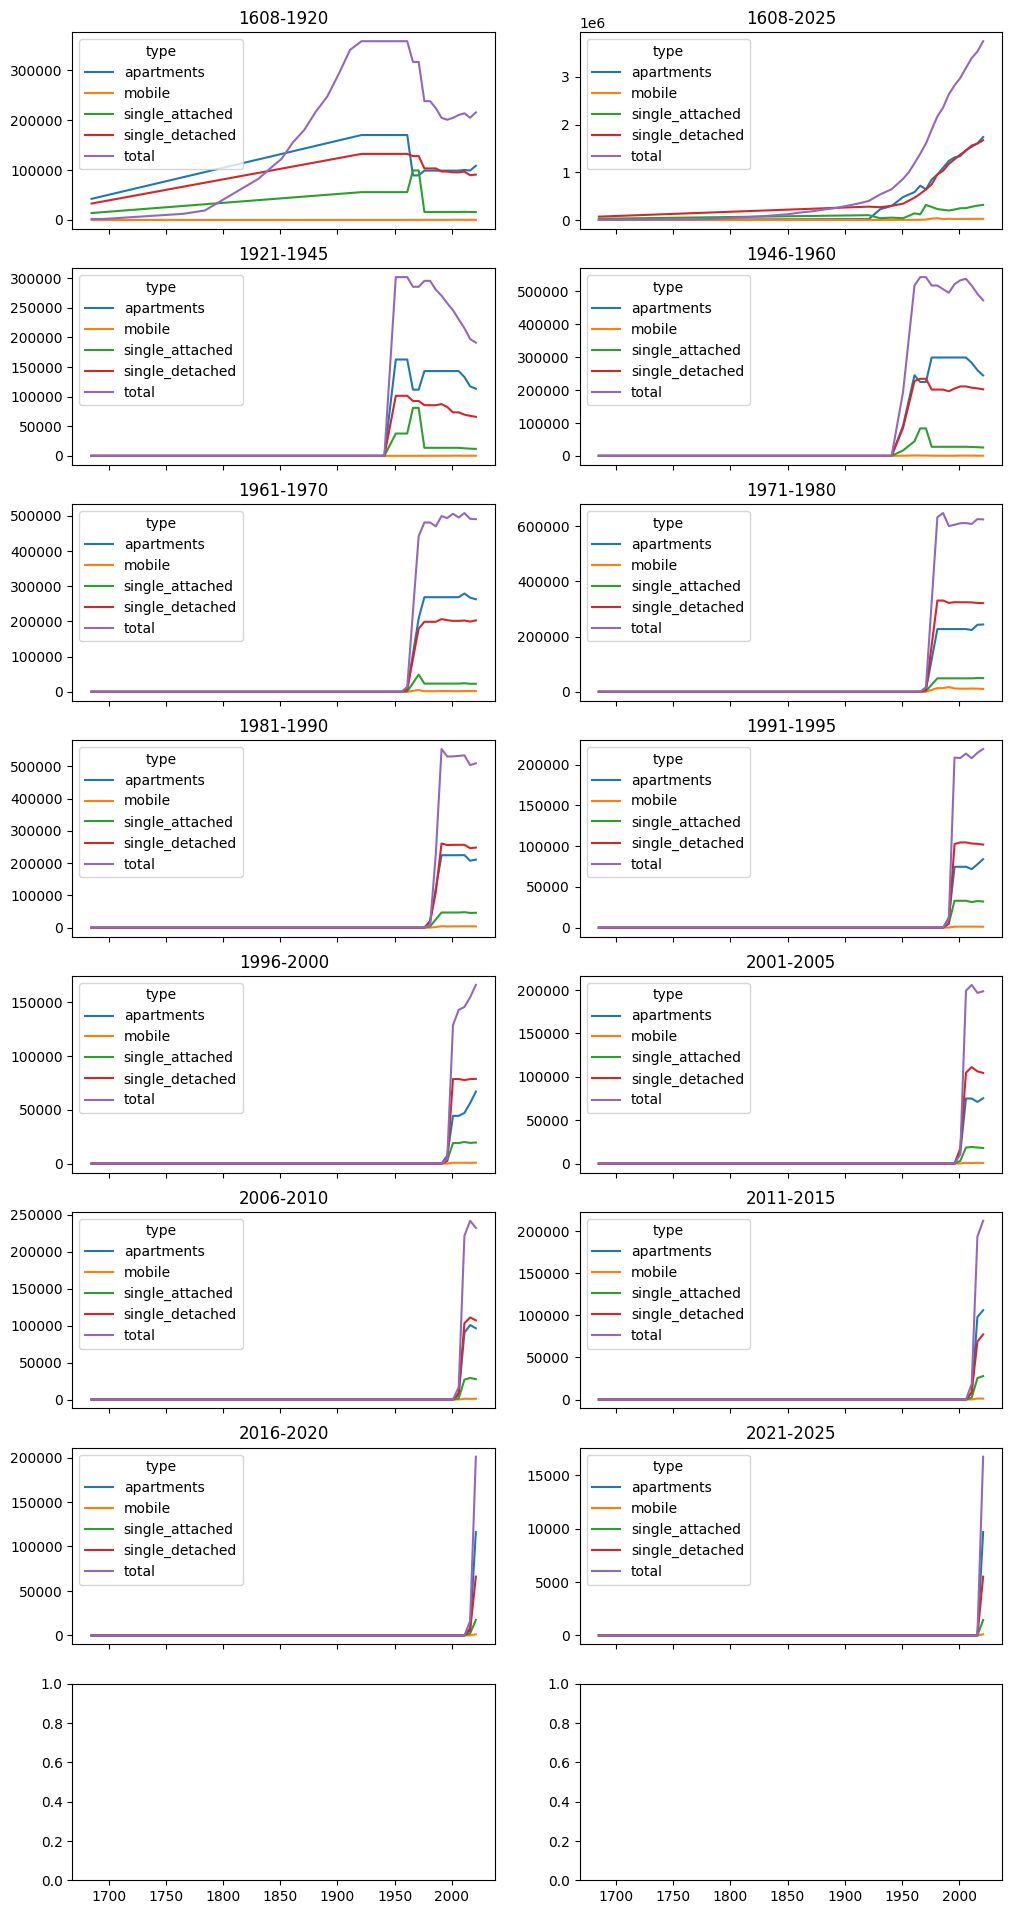

In [20]:
n_vintages = len(combined_method["vintage"].unique())
fig, ax = plt.subplots(
    (n_vintages // 2) + 1,
    2,
    figsize=(12, 3 * ((n_vintages // 2) + 1)),
    sharex=True,
    sharey=False,
)
ax = ax.ravel()

for i, vintage in enumerate(combined_method["vintage"].unique()):
    tempdata = combined_method[
        (combined_method["vintage"] == vintage) & (combined_method["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    # display(tempdata)
    tempdata.plot(ax=ax[i])
    ax[i].set_title(vintage)

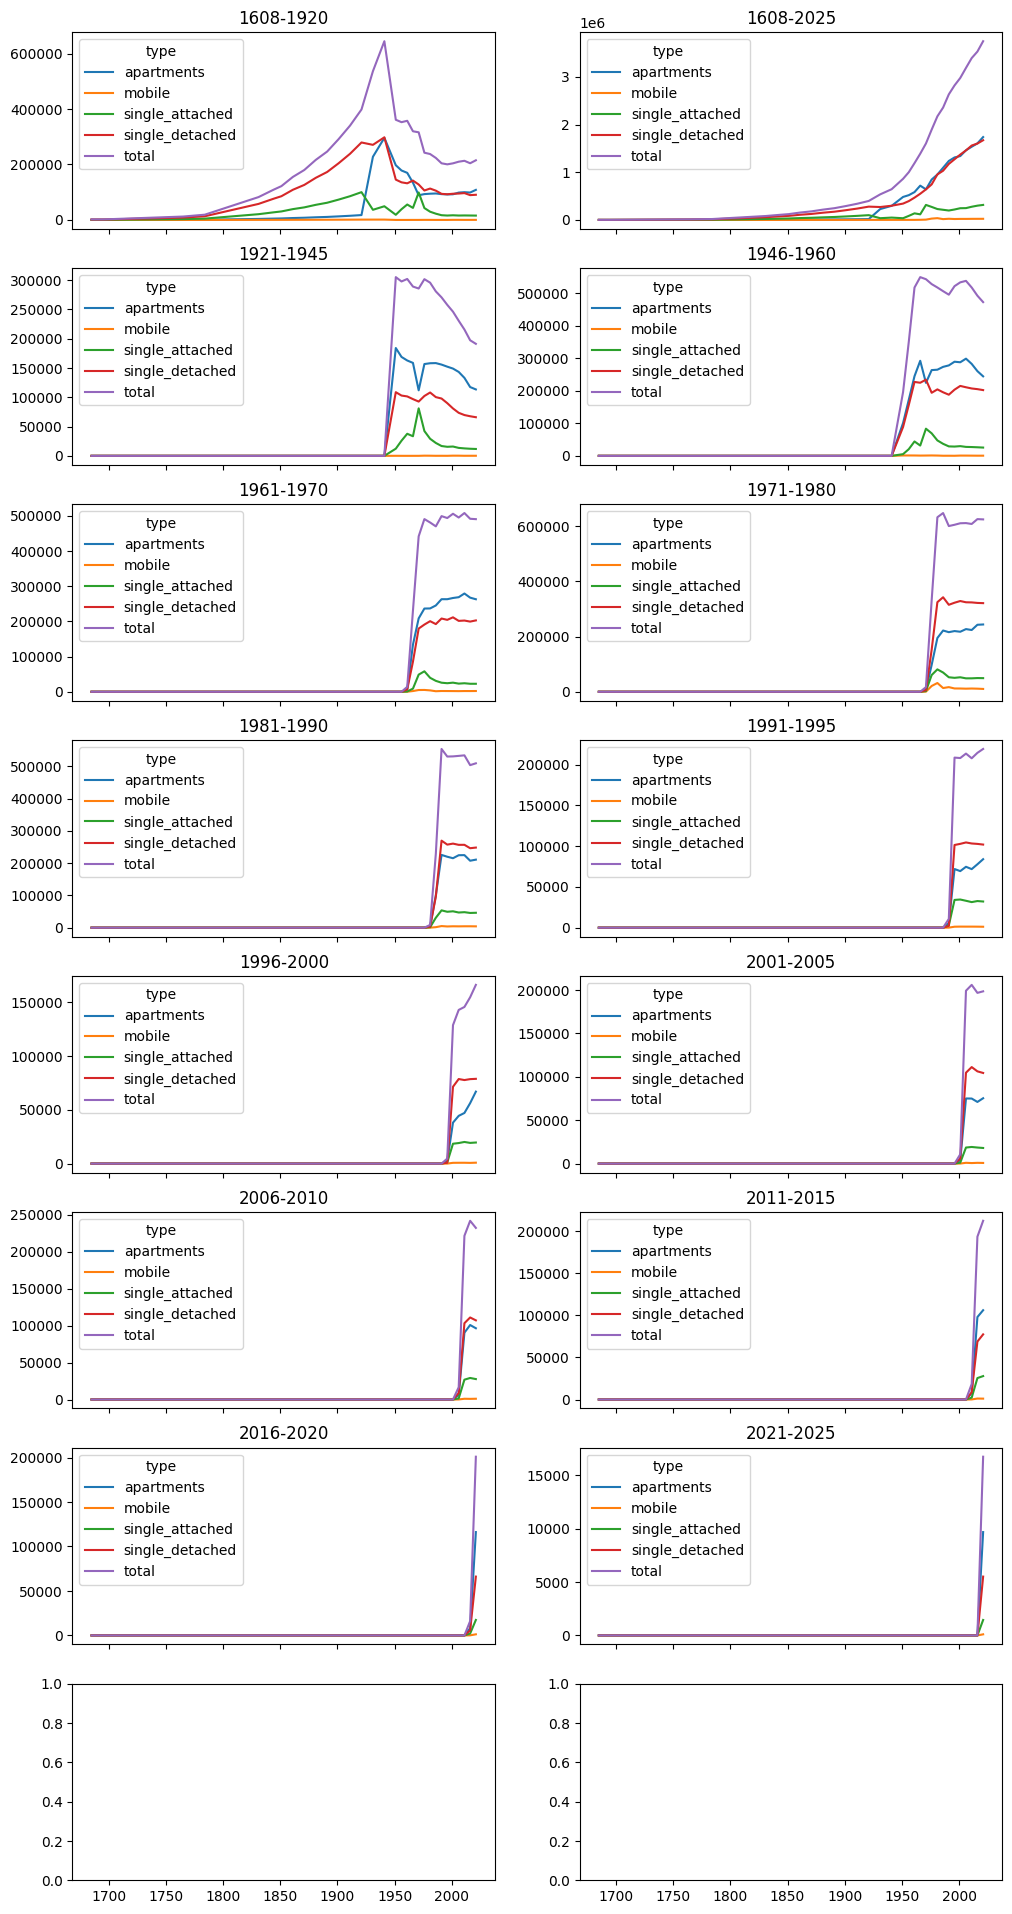

In [21]:
n_vintages = len(c_res["vintage"].unique())
fig, ax = plt.subplots(
    (n_vintages // 2) + 1,
    2,
    figsize=(12, 3 * ((n_vintages // 2) + 1)),
    sharex=True,
    sharey=False,
)
ax = ax.ravel()

for i, vintage in enumerate(c_res["vintage"].unique()):
    tempdata = c_res[
        (c_res["vintage"] == vintage) & (c_res["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    # display(tempdata)
    tempdata.plot(ax=ax[i])
    ax[i].set_title(vintage)

Here, we can see the IPFN clearly did its job by lowering the amount of dwellings, e.g., in 1608-1920; the results in c_res are also noticeably less 'spiky' than the previous attempt, based on year-by-year interpolation (cf res, in first interpolation attempt). we can also see the spikes suggesting lesser quality data, e.g., in 1608-1920 and 1921-1945




In [22]:
# fig, axs = plt.subplots(figsize=(12,8))

# # interpolation #2 (linear + bfill)
# c_res[c_res['type']=='total'].pivot(index='census_year', columns='vintage', values='dwellings').plot(ax=axs)

# # interpolation #1 (year-by-year)
# res[res['type']=='total'].pivot(index='census_year', columns='vintage', values='dwellings').plot(style='--', ax=axs)

# # intial values
# initial_totals.droplevel([0,2], axis=1).plot(style='*', ax=axs)

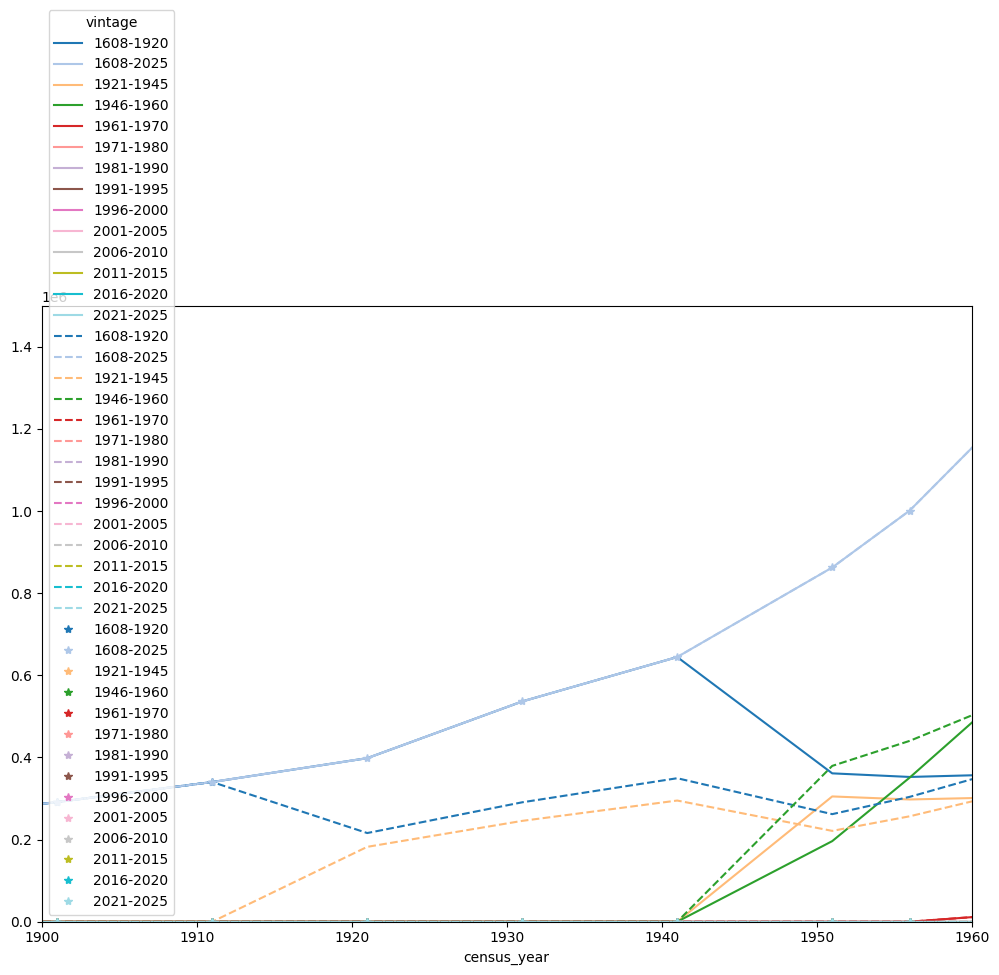

In [23]:
# Get the sorted list of vintages (assumes all dataframes share the same vintage set)
vintage_order = sorted(c_res[c_res['type']=='total']['vintage'].unique())

# Create a color mapping from vintage to a color.
# Here we use a colormap with enough distinct colors (e.g., tab20)
cmap = plt.get_cmap("tab20")
colors_list = [cmap(i) for i in np.linspace(0, 1, len(vintage_order))]
color_map = dict(zip(vintage_order, colors_list))

# Prepare your pivots ensuring the columns appear in the same order
pivot_c_res = c_res[c_res['type']=='total'].pivot(index='census_year', columns='vintage', values='dwellings').reindex(columns=vintage_order)
pivot_res   = res[res['type']=='total'].pivot(index='census_year', columns='vintage', values='dwellings').reindex(columns=vintage_order)
pivot_initial = initial_totals.droplevel([0,2], axis=1).reindex(columns=vintage_order)

# Build the color list in the same order
colors_used = [color_map[v] for v in vintage_order]

fig, axs = plt.subplots(figsize=(12,8))
# Plot interpolation #2 (linear + bfill)
pivot_c_res.plot(ax=axs, color=colors_used)

# Plot interpolation #1 (year-by-year) with dashed style
pivot_res.plot(ax=axs, style='--', color=colors_used)

# Plot initial values using marker style
pivot_initial.plot(ax=axs, style='*', color=colors_used)

axs.set_xlim(1900, 1960)
axs.set_ylim(0, 1.5e6)

plt.show()
# TODO analyse/comparaison des résultats ici

looking here, both methods lead to similar results, EXCEPT for 1608-1920 and 1921-1945 (and, to a lesser extent, 1946-1960). It looks as though the method (linear+bfill) is wrong, as it keeps rising *after* 1921 is over (??); it seems to overestimate, while method (year-by-year) seems to underestimate.

method year-by-year also starts *too soon* for 1921-1945, and *too late* for method linear-bfill. FIXME

all methods start *too soon* for 1946-1960 - it looks like they start in 1941..

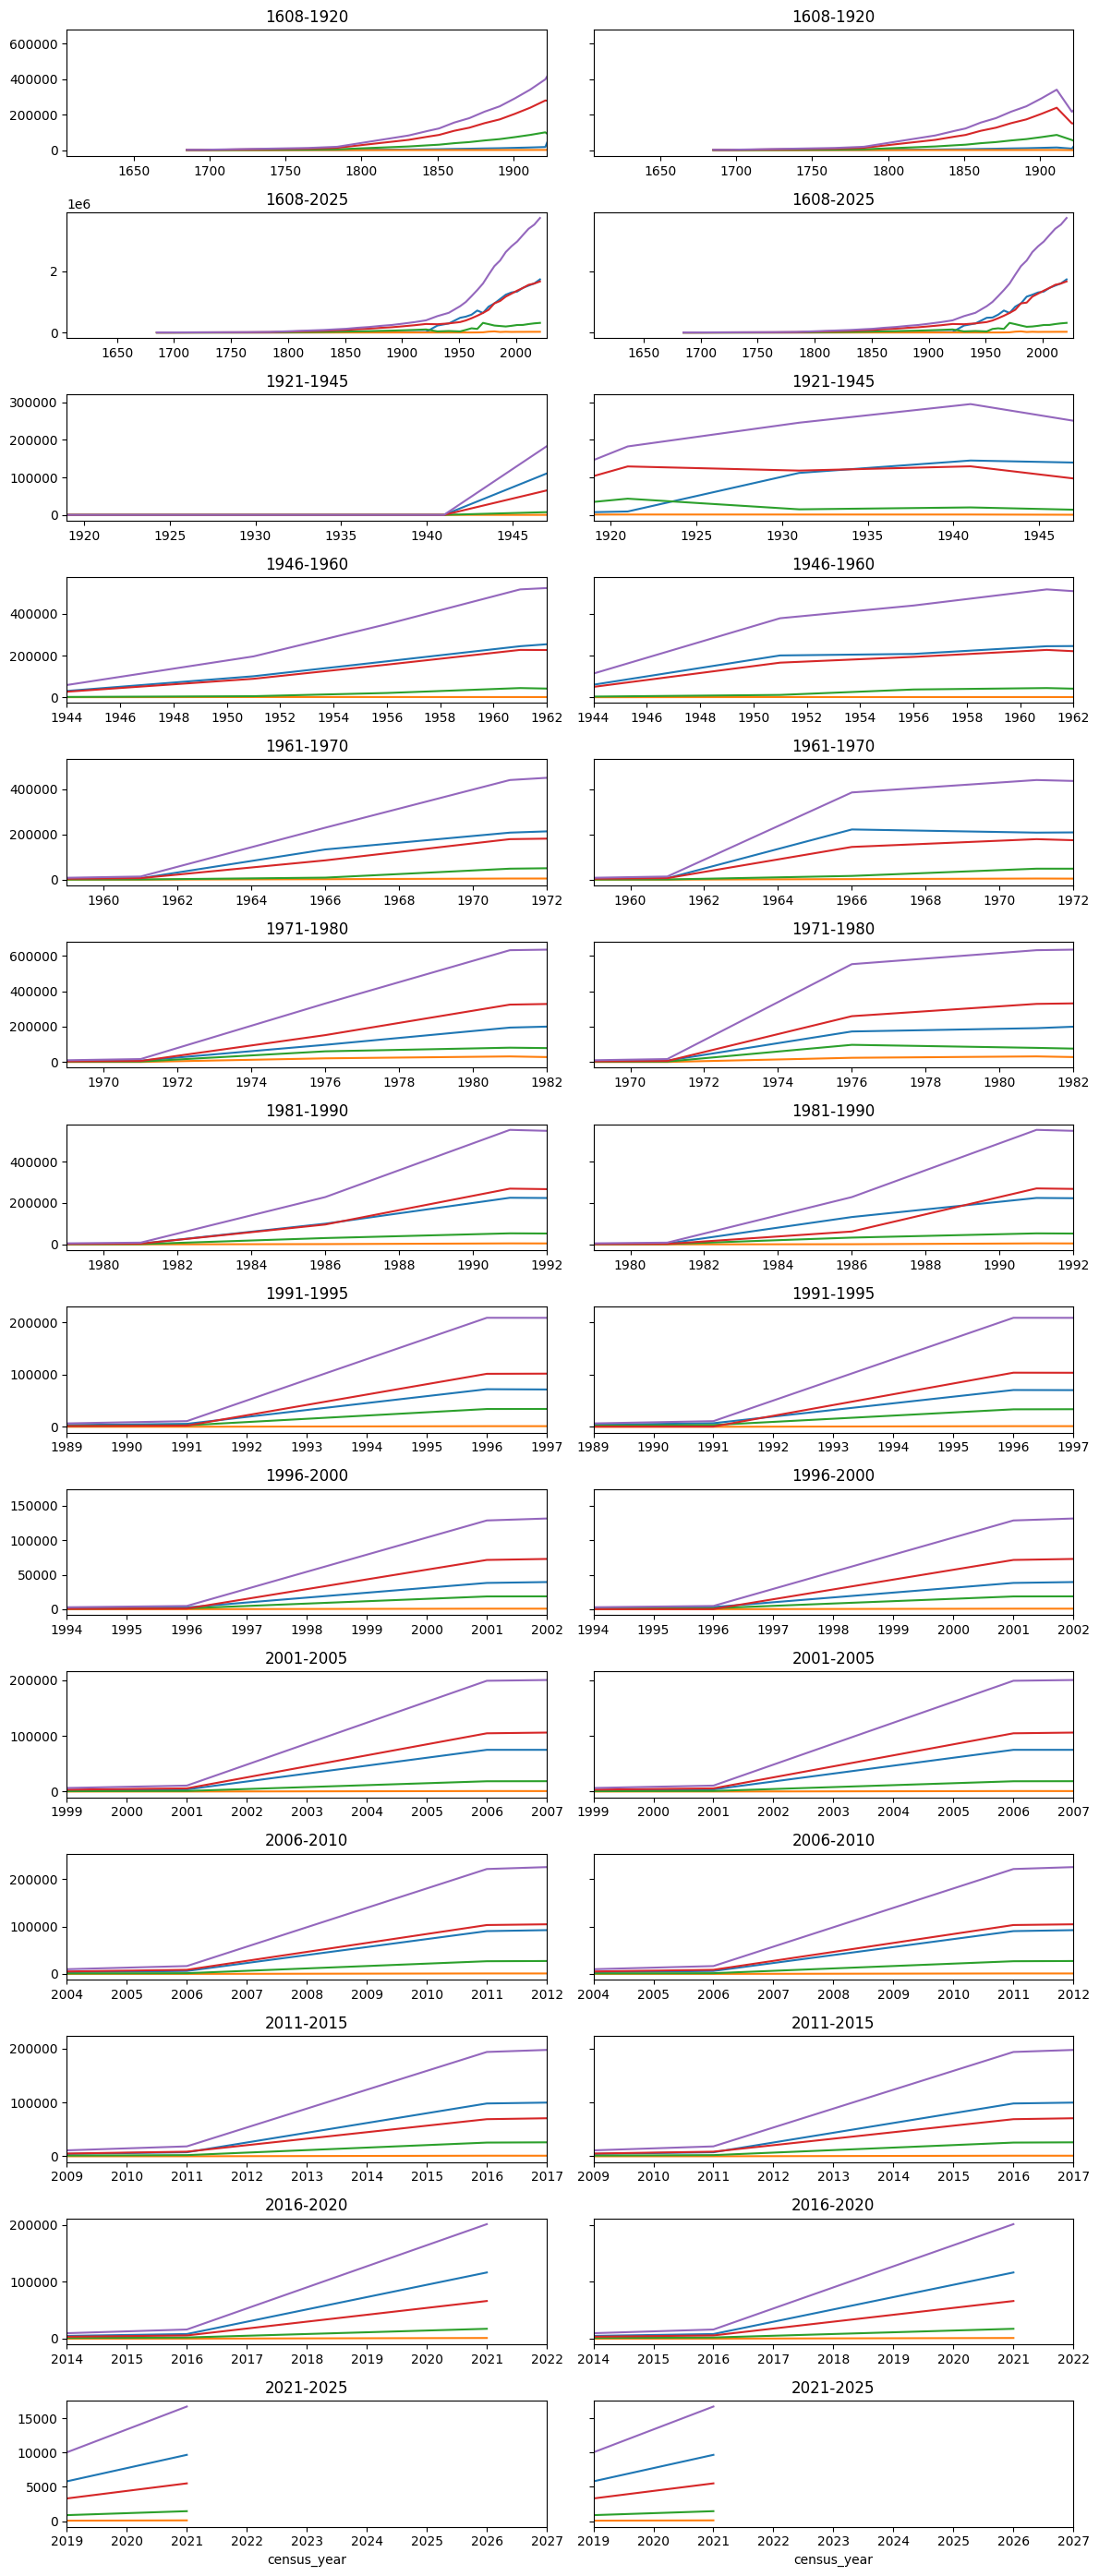

In [24]:
n_vintages = len(c_res["vintage"].unique())
fig, ax = plt.subplots(
    n_vintages,
    2,
    figsize=(12, 2 * n_vintages),
    sharex='row',
    sharey='row',
)

# Plot for "c_res"
for i, vintage in enumerate(c_res["vintage"].unique()):
    tempdata = c_res[
        (c_res["vintage"] == vintage) & (c_res["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    tempdata.plot(ax=ax[i, 0], legend=False)
    ax[i, 0].set_title(vintage)
    xmin, xmax = map(int, vintage.split('-'))
    ax[i, 0].set_xlim([xmin - 2, xmax + 2])

# Plot for "res"
for i, vintage in enumerate(res["vintage"].unique()):
    tempdata = res[
        (res["vintage"] == vintage) & (res["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    tempdata.plot(ax=ax[i, 1], legend=False)
    ax[i, 1].set_title(vintage)
    # Optionally, you can set xlim here similarly if needed.

# Ensure x-axis tick labels are shown on every subplot
# Loop over all axes and force the x-axis labels to be visible
for row in range(n_vintages):
    for col in range(2):
        ax[row, col].tick_params(labelbottom=True)

plt.tight_layout()
plt.show()

Comparing res and c_res shows that :
- c_res does not work *at all* for 1921-1945
- c_res starts too late (i.e., zero in 1961 when these should be end-of-year values, !=0)
- c_res ends too low (the max value of 1961-1970 should be 1970, the same as the next year where decline theoretically starts--thus, last year should be backfilled)

'res' might actually be interesting? however there are issues, as 1921-1945 and 1946-1960 start *too soon* with this method, and have values before the period actually starts, which makes no sense.

## (another) attempt at interpolation

In [25]:
# let's try something new - again, and include the original mask design in unfm_fix

# Use a combined approach - first backfill years outside cohort; then interpolate within cohort, knowing that there must be zero before cohort start
mask_method = []
groups = df3.reset_index().sort_values('census_year').copy().groupby(by=['vintage','type',])

# here, name and group are, e.g., :
"""
('1608-1920', 'apartments')
      census_year    vintage        type  dwellings

1357         1981  1608-1920  apartments        NaN
1338         1986  1608-1920  apartments        NaN
1169         1991  1608-1920  apartments        NaN
950          1996  1608-1920  apartments        NaN
681          2001  1608-1920  apartments        NaN
662          2006  1608-1920  apartments    98660.0
453          2011  1608-1920  apartments   100085.0
322          2016  1608-1920  apartments    98850.0
125          2021  1608-1920  apartments   108425.0
"""
for name, group in list(groups):
    # if name[0] !=  '1961-1970':
    #     continue
    # print(group)
    vintage_start, vintage_end = [int(yr) for yr in name[0].split('-')]
    temp_df = group.copy()

    # retrieve initial mask to make sure that existing, actual data is not overwritten; this mask contains the census years where dwellings is 0 or a known value
    initial_data_mask = temp_df['dwellings'].notna()

    # reindex over full range of census years
    threshold = 10
    itp_df = temp_df.copy().set_index('census_year')
    initial_index = itp_df.index  # save initial index for later (index of intial data in groups) # NOTE is this necessary?
    itp_df = itp_df.reindex(range(vintage_start - 1, max(census_years) + 1))  # NOTE if we use a threshold here, it prevents us from treating cases where the next available data is way after. we should use full period here

    # now, backfill for stable/declining stocks, including the vintage_end value
    mask = itp_df.index.to_series().ge(vintage_end)  # or, mask = itp_df.index >= vintage_end
    itp_df[mask] = itp_df[mask].bfill()

    # using vintage_end value as max dwellings, and knowing that there were no dwellings the year before, we can do a linear interpolation
    itp_df.loc[vintage_start - 1, 'dwellings'] = 0

    itp_df['dwellings'] = itp_df['dwellings'].interpolate(method='index').apply(lambda x: np.ceil(x))  # NOTE: here, I round up to remove decimal fractions of dwellings. this could/should be vectorized
    itp_df['vintage'] = name[0]  # TODO rename to vintage, e.g., '1608-1920'
    itp_df['type'] = name[1]  # TODO rename to type, e.g., 'apartments'

    # display(itp_df.loc[(itp_df.index >= vintage_start) & (itp_df.index <= vintage_end + 5) ])

    # Return the index to the original values (i.e., initial census year values)
    itp_df = itp_df.reindex(initial_index)

    # Overwrite NaNs in temp_df from linear interpolation results. This only overwrites NaNs, and should thus ensure that no original data is overwritten
    temp_df = temp_df.set_index('census_year').combine_first(itp_df).reset_index()
    # display(temp)
    # display(temp_df)

    # retrieve results
    mask_method.append(temp_df)
 


    # # First, backfill for stable/declining stocks
    # mask = temp_df['census_year'].ge(vintage_end)
    # temp_df[mask] = temp_df[mask].bfill()
    # display(temp_df[mask])

    # # NOTE I think the error might come frome here! since I'm filtering on census_year, the vintage end year (1920 in 1608-1920) is NOT being overwritten.
    # # FIXME - ALL ISSUES come from not using yearly values here. 
    # # print(temp_df[mask]) # TODO temp, delete

    # # Second, assume linear growth over the census period
    # # NOTE: what to do with vintage 1608-1920? for several types, there is basically no data from 1685-1921. It *could* have grown, then shrunk. Here, I'll simply assume a linear growth over the full period, which will then get corrected when applying IPFN. Other methods could also be possible. FIXME: 1608-1920 might need another approach---following the growth curve of 'total' values? this might be naturally fixed by the IPFN later; this seems similar to what I did/will do for phd-paper3
    # threshold = 10
    # # mask = temp_df['census_year'].between(vintage_start - 1, vintage_end, inclusive='both') # NOTE here threshold and mask might be a relevant approach, but I don't need them because I work on a copy? see below

    # # the linear interpolation uses a different index, so here I do it on a copy
    # lin_temp = temp_df.copy().set_index('census_year')
    # lin_temp = lin_temp.reindex(range(vintage_start - 1, vintage_end + threshold + 1))  # here, +threshold to account for next census year, and another +1 to include the value in range following year (1930 for 1608-1920)
    # # include year before (e.g., 1607-1920 for 1608-1920)  # NOTE this assumes that vintage_end actually has a value after the bfill() - maybe I should check this beforehand, or default to next year value if it doesn't # FIXME?
    # # temp_df[mask] = temp_df[mask].interpolate
    # lin_temp.loc[vintage_start - 1, 'dwellings'] = 0
    # lin_temp.loc[vintage_end, 'dwellings'] = lin_temp.loc[vintage_end + 1, 'dwellings']  # FIXME instead, this should be 'backfilled' earlier, # TODO # FIXME THIS SHOULD BE A BACKFILL?

    # display(lin_temp)

    # lin_temp['dwellings'] = lin_temp['dwellings'].interpolate(method='index')
    # display(lin_temp)
    # lin_temp['vintage'] = name[0]
    # lin_temp['type'] = name[1]

    # # Fix the indexes of the original df and linear interpoaltion df
    # temp_df = temp_df.set_index(['census_year'])
    # lin_temp = lin_temp.reindex(temp_df.index)

    # # Overwrite NaNs in temp_df from linear interpolation results
    # temp_df = temp_df.combine_first(lin_temp).reset_index()
    # # display(temp)
    # # display(temp_df)

    # retrieve results
    # mask_method.append(temp_df)

# THEN, after the interpolation, fix the marginals
mask_method = pd.concat(mask_method)
# (cont'd)

# NOTE on iterpolation. Over these long periods, I know *nothing* of outflows---use ODYM directly? ACTUALLY, this is completely artificial- IF I 'FORCE' stock levels in this way, am I not 'forcing' inflows and 'outflows'? Why am I doing this-- just to compare with the results of ODYM, which relies on population, lifetime, and typesplit? Is this just for comparison? This is mostly a concern for the 1608-1920, which definitely includes outflows. For shorter cohorts,  this might not be such an issue. FIXME -- maybe need to show the difference between 'real' initial data, 'fixed' (interpolated, ipfn) data, and ODYM results?

# NOTE/FIXME: why don't I just keep the full interpolated index instead of only selected census years?

In [ ]:
# Fix the marginals and run IPFN
masked_df = {}
for year in census_years:
    print(f" === Census {year} === ")
    # Take individual census_year
    tsplit5 = mask_method.set_index('census_year').loc[year, :].pivot(
        index="vintage", columns="type", values="dwellings"
    ).reset_index()
    # display(tsplit5)
    new_data, diff = itp.reconcile_data_with_marginals(tsplit5)
    # new_data.stack().reset_index()  # FIXME to add year back?
    # new_data['census_year'] = year  # FIXME to add year back?
    masked_df[year] = new_data
    # display(diff)  # can be useful for documentation; maybe check max/min value to see largest diff

m_res = pd.concat(masked_df).stack('type').reset_index().rename(columns={"level_0":"census_year", 0:'dwellings'})
display(m_res)


Modified type marginals: 10.0 units ([5. 0. 1. 4.]) from {"apartments":1738185.0,"mobile":23640.0,"single_attached":315105.0,"single_detached":1672095.0}
Modified cohort marginals: -5.0 units ([ 0.  0. -1. -1. -1. -1.  0.  0.  0. -1.  0.  0.  0.]) from {"1608-1920":215130.0,"1921-1945":191220.0,"1946-1960":473025.0,"1961-1970":490395.0,"1971-1980":624300.0,"1981-1990":509125.0,"1991-1995":219080.0,"1996-2000":166240.0,"2001-2005":198590.0,"2006-2010":231935.0,"2011-2015":212285.0,"2016-2020":200968.0,"2021-2025":16747.0}
Sum of IPFN adjustment difference: 10.02
Modified type marginals: -10.0 units ([-5.  0. -1. -4.]) from {"apartments":1606150.0,"mobile":23295.0,"single_attached":299550.0,"single_detached":1602675.0}
Modified cohort marginals: -5.0 units ([ 0.  0. -1. -1. -1. -1.  0.  0.  0. -1.  0.  0.]) from {"1608-1920":204420.0,"1921-1945":197305.0,"1946-1960":492770.0,"1961-1970":491450.0,"1971-1980":625310.0,"1981-1990":503495.0,"1991-1995":214310.0,"1996-2000":154710.0,"2001-200

 === Census 2021 === 
type         total  apartments  mobile  single_attached  single_detached
vintage                                                                 
1608-1920   215130      108425     235            15700            90780
1608-2025  3749035     1738190   23640           315106          1672099
1921-1945   191220      113375     155            11755            65940
1946-1960   473024      244625     545            25510           202345
1961-1970   490394      262830    2160            22690           202695
1971-1980   624299      243705   10290            49315           320995
1981-1990   509124      210730    4105            46165           248120
1991-1995   219080       83955    1150            32085           101885
1996-2000   166240       66940     850            19605            78840
2001-2005   198590       75350     745            18005           104490
2006-2010   231934       96310    1030            27615           106985
2011-2015   212285      10607

Modified type marginals: 10.0 units ([5. 0. 1. 4.]) from {"apartments":1461445.0,"mobile":21545.0,"single_attached":247945.0,"single_detached":1458400.0}
Modified cohort marginals: 15.0 units ([1. 1. 3. 2. 3. 2. 1. 1. 1. 0.]) from {"1608-1920":210025.0,"1921-1945":230575.0,"1946-1960":538440.0,"1961-1970":494995.0,"1971-1980":610930.0,"1981-1990":532115.0,"1991-1995":213405.0,"1996-2000":142945.0,"2001-2005":199292.0,"2006-2010":16608.0}
Sum of IPFN adjustment difference: 10.0
Modified cohort marginals: 5.0 units ([0. 1. 1. 1. 1. 1. 0. 0. 0.]) from {"1608-1920":204125.0,"1921-1945":246100.0,"1946-1960":533870.0,"1961-1970":505720.0,"1971-1980":610275.0,"1981-1990":530580.0,"1991-1995":207945.0,"1996-2000":128765.0,"2001-2005":10730.0}
Sum of IPFN adjustment difference: -35175.98
Marginals fit; no modifications required.
Sum of IPFN adjustment difference: -27064.99
Modified type marginals: 390.0 units ([183.   4.  29. 174.]) from {"apartments":1236945.0,"mobile":24605.0,"single_attached

type           total  apartments   mobile  single_attached  single_detached
vintage                                                                    
1608-1920   210026.0     98660.0    310.0          15905.0          95160.0
1608-2025  3189345.0   1461450.0  21545.0         247946.0        1458404.0
1921-1945   230576.0    143240.0    290.0          13580.0          73465.0
1946-1960   538443.0    299060.0    790.0          27545.0         211040.0
1961-1970   494997.0    268650.0   1800.0          23155.0         201390.0
1971-1980   610933.0    226990.0  11215.0          48620.0         324100.0
1981-1990   532117.0    224440.0   4105.0          46985.0         256580.0
1991-1995   213406.0     74655.0   1290.0          32985.0         104480.0
1996-2000   142946.0     44410.0    760.0          19115.0          78660.0
2001-2005   199293.0     75079.0    914.0          18513.0         104792.0
2006-2010    16608.0      6256.0     76.0           1542.0           8733.0
 === Census 

Sum of IPFN adjustment difference: -18545.01
Modified type marginals: 5.0 units ([2. 0. 1. 2.]) from {"apartments":952700.0,"mobile":37155.0,"single_attached":228545.0,"single_detached":954455.0}
Modified cohort marginals: 5.0 units ([1. 1. 1. 1. 1. 0.]) from {"1608-1920":237670.0,"1921-1945":295620.0,"1946-1960":518040.0,"1961-1970":480890.0,"1971-1980":632060.0,"1981-1990":8575.0}
Sum of IPFN adjustment difference: 26887.99
Modified type marginals: 1.0 units ([1. 0. 0. 0.]) from {"apartments":847430.0,"mobile":27885.0,"single_attached":273200.0,"single_detached":745595.0}
Modified cohort marginals: 3268.0 units ([411. 511. 895. 831. 620.]) from {"1608-1920":237670.0,"1921-1945":295620.0,"1946-1960":518040.0,"1961-1970":480890.0,"1971-1980":358623.0}
Sum of IPFN adjustment difference: 61793.01
Modified cohort marginals: 5.0 units ([1. 1. 2. 1. 0.]) from {"1608-1920":316030.0,"1921-1945":285630.0,"1946-1960":543550.0,"1961-1970":441645.0,"1971-1980":16825.0}
Sum of IPFN adjustment diff

...

 === Census 1871 === 
type          total  apartments  mobile  single_attached  single_detached
vintage                                                                  
1608-1920  180115.0    143253.0     5.0          46914.0         111421.0
1608-2025  180115.0      7947.0   520.0          45315.0         126333.0
 === Census 1861 === 
type          total  apartments  mobile  single_attached  single_detached
vintage                                                                  
1608-1920  155088.0    137827.0     5.0          45137.0         107201.0
1608-2025  155088.0      6842.0   448.0          39019.0         108779.0
 === Census 1851 === 
type          total  apartments  mobile  single_attached  single_detached
vintage                                                                  
1608-1920  121961.0    132401.0     4.0          43360.0         102980.0
1608-2025  121961.0      5381.0   353.0          30684.0          85543.0
 === Census 1844 === 
type          total  apa

Sum of IPFN adjustment difference: -183281.0
Modified type marginals: -188107.0 units ([  -8299.    -544.  -47326. -131938.]) from {"apartments":8839.0,"mobile":579.0,"single_attached":50403.0,"single_detached":140516.0}
Sum of IPFN adjustment difference: -168270.0
Modified type marginals: -113075.0 units ([ -4989.   -327. -28449. -79310.]) from {"apartments":5091.0,"mobile":334.0,"single_attached":29030.0,"single_detached":80930.0}
Sum of IPFN adjustment difference: -101649.0
Modified type marginals: -109647.0 units ([ -4838.   -317. -27586. -76906.]) from {"apartments":4923.0,"mobile":323.0,"single_attached":28073.0,"single_detached":78262.0}
Sum of IPFN adjustment difference: -98598.0
Modified type marginals: -105848.0 units ([ -4670.   -306. -26631. -74241.]) from {"apartments":4755.0,"mobile":312.0,"single_attached":27116.0,"single_detached":75594.0}
Sum of IPFN adjustment difference: -95176.0
Modified type marginals: -100829.0 units ([ -4449.   -292. -25368. -70720.]) from {"apar

 === Census 1765 === 
type         total  apartments  mobile  single_attached  single_detached
vintage                                                                 
1608-1920  12230.0     85735.0     3.0          28078.0          66684.0
1608-2025  12230.0       540.0    35.0           3077.0           8578.0
 === Census 1698 === 
type        total  apartments  mobile  single_attached  single_detached
vintage                                                                
1608-1920  2310.0     49379.0     2.0          16171.0          38407.0
1608-2025  2310.0       102.0     7.0            581.0           1620.0
 === Census 1695 === 
type        total  apartments  mobile  single_attached  single_detached
vintage                                                                
1608-1920  1934.0     47751.0     2.0          15638.0          37141.0
1608-2025  1934.0        85.0     6.0            487.0           1356.0
 === Census 1692 === 
type        total  apartments  mobile  singl

Sum of IPFN adjustment difference: -87118.0


,census_year,vintage,type,dwellings
0,2021,1608-1920,total,215130
1,2021,1608-1920,apartments,108419
2,2021,1608-1920,mobile,235
3,2021,1608-1920,single_attached,15700
4,2021,1608-1920,single_detached,90776
...,...,...,...,...
2375,1685,2021-2025,total,0
2376,1685,2021-2025,apartments,0
2377,1685,2021-2025,mobile,0
2378,1685,2021-2025,single_attached,0


In [27]:
mask_method[
        (mask_method["vintage"] == "1961-1970") & (mask_method["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    # NOTE this is pre-IPFN data !!

type,apartments,mobile,single_attached,single_detached,total
census_year,,,,,
1685,0.0,0.0,0.0,0.0,0.0
1688,0.0,0.0,0.0,0.0,0.0
1692,0.0,0.0,0.0,0.0,0.0
1695,0.0,0.0,0.0,0.0,0.0
1698,0.0,0.0,0.0,0.0,0.0
1765,0.0,0.0,0.0,0.0,0.0
1784,0.0,0.0,0.0,0.0,0.0
1831,0.0,0.0,0.0,0.0,0.0
1844,0.0,0.0,0.0,0.0,0.0


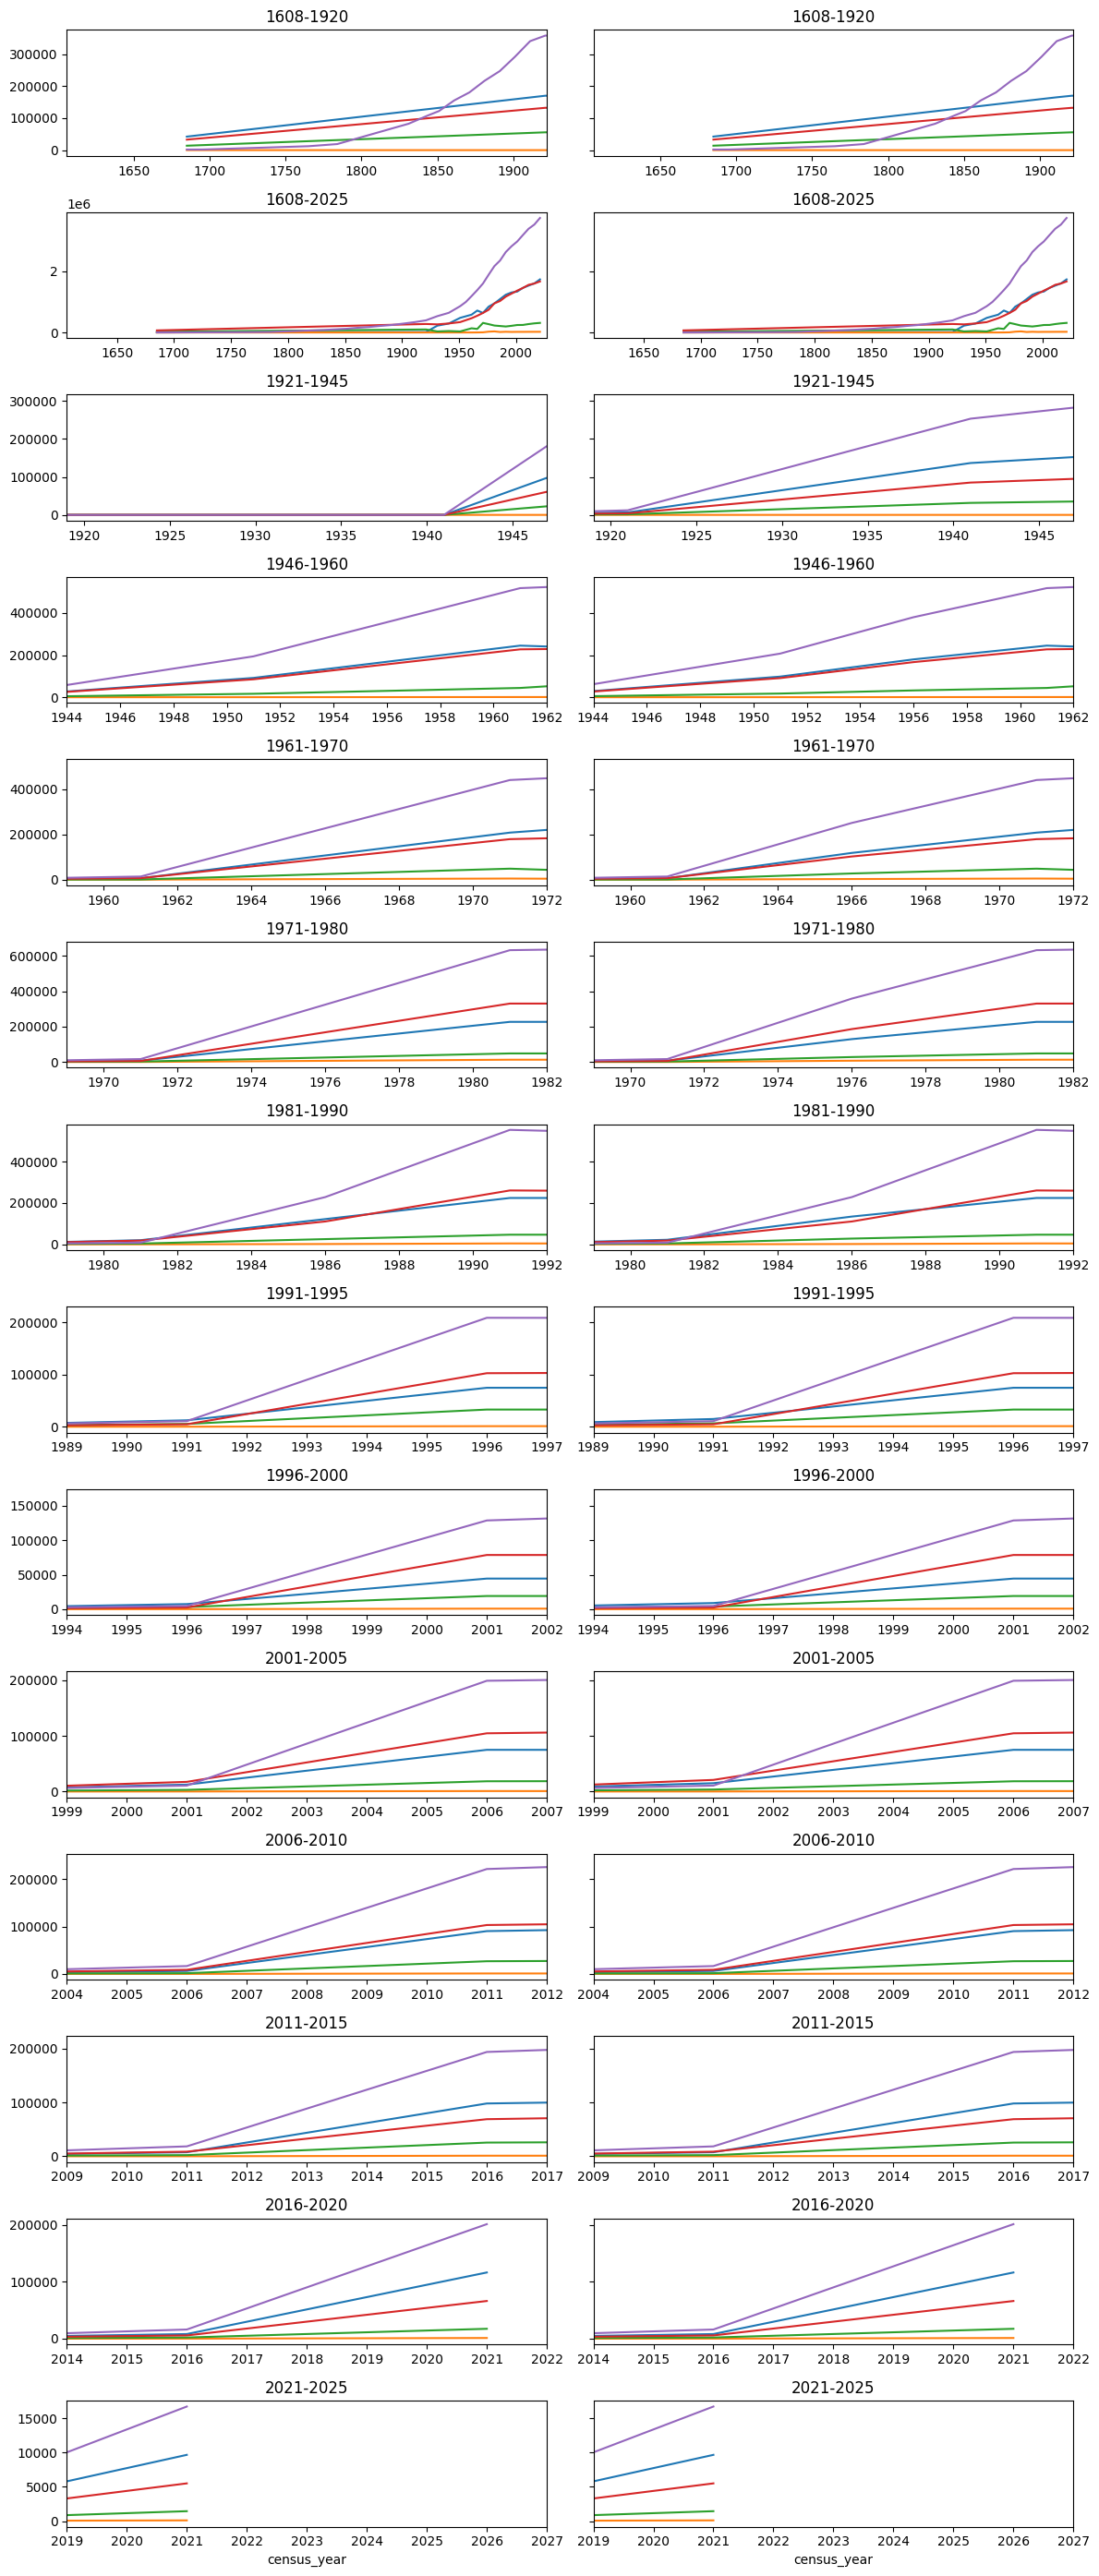

In [28]:
n_vintages = len(combined_method["vintage"].unique())
fig, ax = plt.subplots(
    n_vintages,
    2,
    figsize=(12, 2 * n_vintages),
    sharex='row',
    sharey='row',
)

# Plot for "combined_method"
for i, vintage in enumerate(combined_method["vintage"].unique()):
    tempdata = combined_method[
        (combined_method["vintage"] == vintage) & (combined_method["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    tempdata.plot(ax=ax[i, 0],
                  legend=False,
                #   style='o'
    )
    ax[i, 0].set_title(vintage)
    xmin, xmax = map(int, vintage.split('-'))
    ax[i, 0].set_xlim([xmin - 2, xmax + 2])

# Plot for "mask_method"
for i, vintage in enumerate(mask_method["vintage"].unique()):
    tempdata = mask_method[
        (mask_method["vintage"] == vintage) & (mask_method["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    tempdata.plot(ax=ax[i, 1],
                  legend=False,
                #   style='o'
    )
    ax[i, 1].set_title(vintage)
    # Optionally, you can set xlim here similarly if needed.

# Ensure x-axis tick labels are shown on every subplot
# Loop over all axes and force the x-axis labels to be visible
for row in range(n_vintages):
    for col in range(2):
        ax[row, col].tick_params(labelbottom=True)

plt.tight_layout()
plt.show()

When drawing these as lines, there are visual artifacts since the lines are drawn from few points. For instance,:
- some years like 1921-1945, 1946-1960 and 1961-1970 appear to 'cap' too late, for instance in 1972 instead of in 1971.

I had a look at the data, and it seems fine. The interpolation function does its job correctly. These are minimal differences - at first, I believe they were introduced by `reconcile_data_with_marginals(tsplit5)`,however this is impossible as 'combined_method' and 'mask_method' are pre-IPFN. They are simply artifacts of pandas trying to interpolate to produce a lineplot. In the case of 1946-1960, the values appear to 'start' before 1946 and 'end' after 1960 because the only data points in the graph are 1941, 1951, 1956 and 1961. The interpolation approach works, but the rendering as a lineplot suggests an error that isn't there. 

On that topic, it might actually not be necessary to go 'back' to the original index - perhaps it would be better to keep all the interpolated points? Or maybe not - after all, this is just an interpolation procedure, not 'real' data, and we have no idea about the actual counts (incl. conversions, demolitions, representative outflows due to lifetime, etc.).

(FIXED) **However**, compared to c_res and m_res, the method puts *way* too many dwellings in early censuses. The 'total' is OK, but the individual values by type are 2 orders of magnitude too large.
- NOTE: this is normal, because mask_method is BEFORE IPFN.

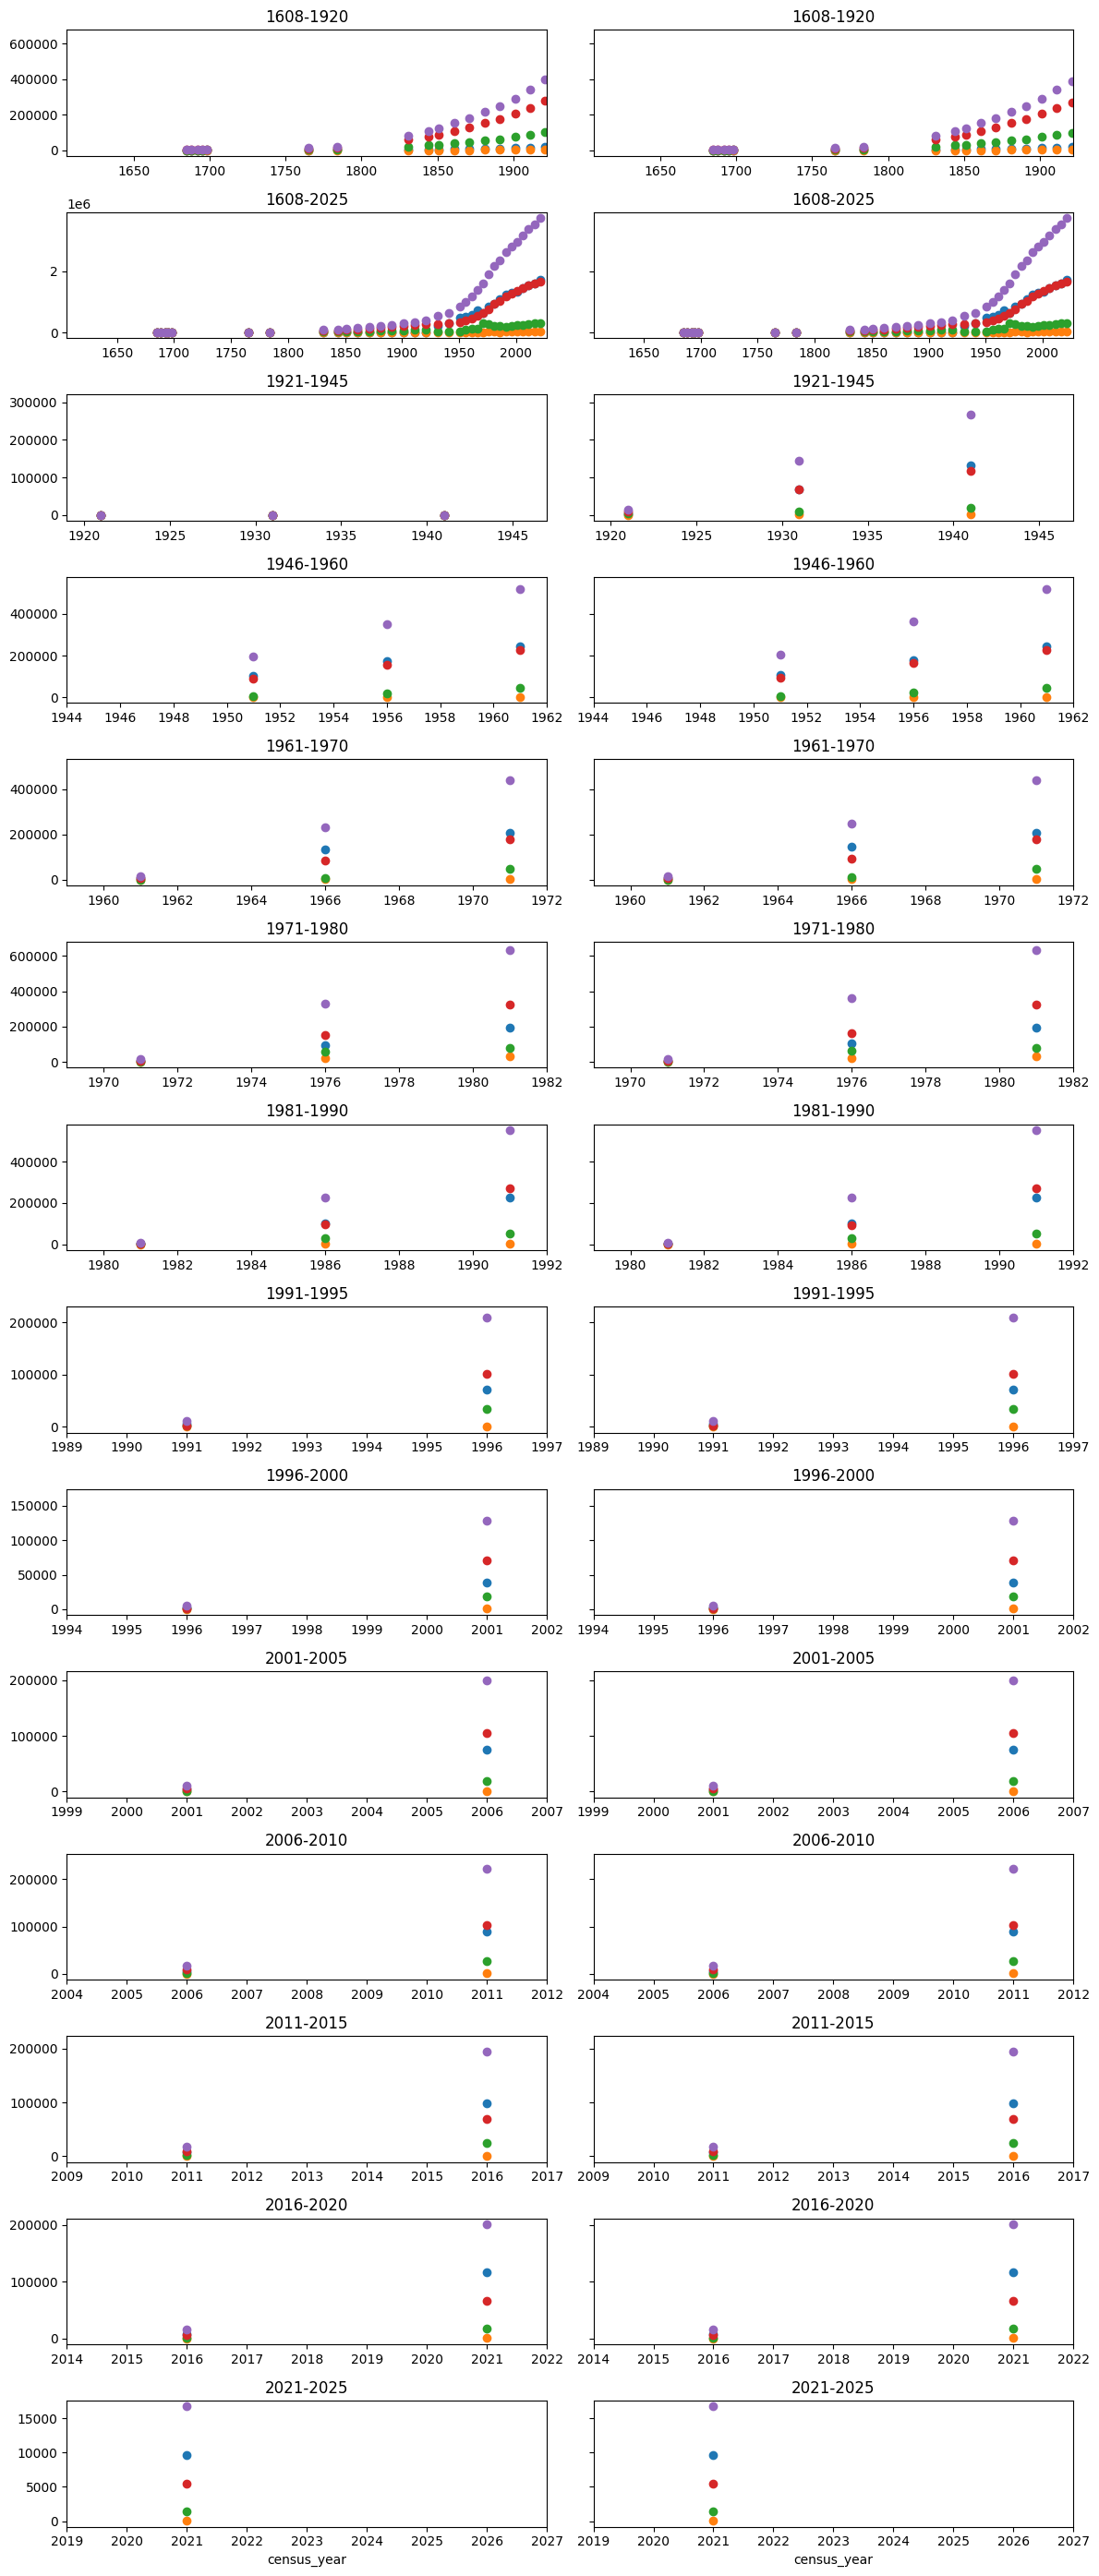

In [29]:
n_vintages = len(c_res["vintage"].unique())
fig, ax = plt.subplots(
    n_vintages,
    2,
    figsize=(12, 2 * n_vintages),
    sharex='row',
    sharey='row',
)

# Plot for "c_res"
for i, vintage in enumerate(c_res["vintage"].unique()):
    tempdata = c_res[
        (c_res["vintage"] == vintage) & (c_res["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    tempdata.plot(ax=ax[i, 0], legend=False, style='o')
    ax[i, 0].set_title(vintage)
    xmin, xmax = map(int, vintage.split('-'))
    ax[i, 0].set_xlim([xmin - 2, xmax + 2])

# Plot for "m_res"
for i, vintage in enumerate(m_res["vintage"].unique()):
    tempdata = m_res[
        (m_res["vintage"] == vintage) & (m_res["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings")
    tempdata.plot(ax=ax[i, 1], legend=False, style='o')
    ax[i, 1].set_title(vintage)
    # Optionally, you can set xlim here similarly if needed.

# Ensure x-axis tick labels are shown on every subplot
# Loop over all axes and force the x-axis labels to be visible
for row in range(n_vintages):
    for col in range(2):
        ax[row, col].tick_params(labelbottom=True)

plt.tight_layout()
plt.show()

In [30]:
m_res.loc[m_res['census_year']==1685].pivot(index='vintage', columns='type', values='dwellings')

type,apartments,mobile,single_attached,single_detached,total
vintage,,,,,
1608-1920,88,6,500,1396,1990
1608-2025,88,6,500,1396,1990
1921-1945,0,0,0,0,0
1946-1960,0,0,0,0,0
1961-1970,0,0,0,0,0
1971-1980,0,0,0,0,0
1981-1990,0,0,0,0,0
1991-1995,0,0,0,0,0
1996-2000,0,0,0,0,0


Comparing m_res and c_res shows that both methods produce similar results, *except* for 1921-1945 where the mask-method + IPFN is way better. The results seem sound, and fit with the expected totals.

This seems perfectly fine. One potential remaining issue is that the resulting values seem a bit different from the original dataset (unfm_fix) from 'bac'. This *could* be because I'm not protecting the original data in the IPFN.

## Protecting data in IPFN


In [77]:
# Define a sample dataframe
sample_df = pd.DataFrame({
        "vintage": ["1608-2025", "1608-1920", "1921-1945", "1946-1960", "2020-2025"],
        "total": [800, 260, 300, 240, 0],
        "single_attached": [100, 20, 50, 30, 0],
        "apartments": [220, 80, 100, 40, 0],
        "single_detached": [280, 100, 120, 60, 0],
        "mobile": [200, 80, 80, 40, 0],
        "some_other_col": [None, None, None, None, None],
    })

# Define a sample mask with original (True) and missing (False) data
sample_mask = pd.DataFrame(True, index=sample_df.index, columns=sample_df.columns)
sample_mask['some_other_col'] = False  # TODO test with a 'false' at 0?
sample_mask.loc[2:3, 'mobile'] = False
sample_mask.loc[1:2, 'single_attached'] = False
sample_mask.loc[4, 'apartments'] = False

# Apply mask to sample df
sample_df[sample_mask]

,vintage,total,single_attached,apartments,single_detached,mobile,some_other_col
0,1608-2025,800,100.0,220.0,280,200.0,NaN
1,1608-1920,260,NaN,80.0,100,80.0,NaN
2,1921-1945,300,NaN,100.0,120,NaN,NaN
3,1946-1960,240,30.0,40.0,60,NaN,NaN
4,2020-2025,0,0.0,NaN,0,0.0,NaN


In [78]:
# Run IPFN using partial data; 
orig_data = sample_df[sample_mask].copy()

# Calculate new marginals
orig_data.loc[1:, 'total'] -= orig_data.loc[1:, 'single_attached':].sum(axis=1)  # 'total', i.e., sum over cols
orig_data.loc[0, 'single_attached':] -= orig_data.loc[1:, 'single_attached':].sum(axis=0)  # '1608-2025', sum over rows

# Calculate new total
orig_data.loc[0, 'total'] -= orig_data.loc[1:, 'single_attached':].sum(axis=0).sum()

# Remove 'known' data
orig_data.loc[1:, 'single_attached':] -= orig_data.loc[1:, 'single_attached':]

input_df = orig_data.combine_first(sample_df).replace(0,0.1)

# I might instead make sure that there are absolutely no zeros in marginals? But then, there remains the issue of running ipfn with '0' values in it. the previous approach only worked for definite cases with rows with values, and rows with zeroes.
# input_df.loc[0,:] = input_df.loc[0,:].replace(0, 0.1)
# input_df.loc[:,'total'] = input_df.loc[:,'total'].replace(0, 0.1)
input_df

/tmp/ipykernel_18522/1329961943.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.0 80.0 110.0 0.0]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  orig_data.loc[1:, 'total'] -= orig_data.loc[1:, 'single_attached':].sum(axis=1)  # 'total', i.e., sum over cols
/tmp/ipykernel_18522/1329961943.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_df = orig_data.combine_first(sample_df).replace(0,0.1)


,vintage,total,single_attached,apartments,single_detached,mobile,some_other_col
0,1608-2025,190.0,70.0,0.1,0.1,120.0,NaN
1,1608-1920,0.1,20.0,0.1,0.1,0.1,NaN
2,1921-1945,80.0,50.0,0.1,0.1,80.0,NaN
3,1946-1960,110.0,0.1,0.1,0.1,40.0,NaN
4,2020-2025,0.1,0.1,0.1,0.1,0.1,NaN


In [82]:
import importlib
importlib.reload(itp)

new, diff = itp.reconcile_data_with_marginals(input_df, protect_original=True)
display(new)
# If there are zeros in, e.g., 1608-2025, it breaks

==================== New run at 2025-10-22 12:01:02 ====================
Successfully loaded config from /home/cbreton/dev/cbreton026/uncertimety/data/config.toml
Modified type marginals: -0.2 units ([-0.1  0.   0.  -0.1]) from {"apartments":0.1,"mobile":120.0,"single_attached":70.0,"single_detached":0.1}
Modified cohort marginals: -0.2 units ([-0.1  0.   0.  -0.1]) from {"1608-1920":0.1,"1921-1945":80.0,"1946-1960":110.0,"2020-2025":0.1}
Sum of IPFN adjustment difference: -1.01


           total  apartments  mobile  single_attached  single_detached
vintage                                                               
1608-2025  190.0         0.1   120.0             70.0              0.1
1608-1920    0.1         0.1     0.1             20.0              0.1
1921-1945   80.0         0.1    80.0             50.0              0.1
1946-1960  110.0         0.1    40.0              0.1              0.1
2020-2025    0.1         0.1     0.1              0.1              0.1


,total,apartments,mobile,single_attached,single_detached
vintage,,,,,
1608-2025,190,0,120,70,0
1608-1920,0,0,0,0,0
1921-1945,80,0,12,67,0
1946-1960,110,0,107,2,0
2020-2025,0,0,0,0,0


In [89]:
# NOTE: here, we can see that some values are mistakenly added to 'original' data; there are "2" single_attached dwellings that are added, but will be overwritten later on. This might lead to slight inaccuracies. FIXME
new.reset_index()[sample_mask]#.drop(0, axis=0).drop('total', axis=1)

,vintage,total,apartments,mobile,single_attached,single_detached
0,1608-2025,190,0.0,120.0,70.0,0
1,1608-1920,0,0.0,0.0,NaN,0
2,1921-1945,80,0.0,NaN,NaN,0
3,1946-1960,110,0.0,NaN,2.0,0
4,2020-2025,0,NaN,0.0,0.0,0


In [131]:
display(new.reset_index()[~other_mask])
# Some cleaning up is necessary; if not, we can see the small inconsistencies; we might need to do a round_consistent_sum pass if we are to delete them? I tested this, however round_consistent_sum actually *causes* the splitting behaviour (splitting the difference over several numbers). the pass needs to happen only on modified data, here :new.reset_index()[~sample_mask] 
# get custom mask
other_mask = sample_mask.copy()
other_mask[['vintage','total']] = False
other_mask.loc[0,:] = False

rcs_data = new.reset_index()[~other_mask].to_numpy()

# Extract vintage labels, desired sums and component values
vintage = rcs_data[:, 0]
desired = rcs_data[:, 1].astype(float)
components = rcs_data[:, 2:].astype(float)

# Compute the current sum of components for each row
current_sum = np.nansum(components, axis=1)

# Compute the scale factor for each row (avoid division by zero)
with np.errstate(divide="ignore", invalid="ignore"):
    scale = np.where(current_sum != 0, desired / current_sum, 0)

# Multiply components by the row-wise scale factor. We reshape scale to (n,1) to broadcast correctly
new_components = np.round(components * scale[:, None])

# Put the results back together
new_rcs_data = np.hstack([vintage.reshape(-1, 1),
                      desired.reshape(-1, 1),
                      new_components])

new_rcs_data = pd.DataFrame(new_rcs_data, index=new.reset_index().index, columns=new.reset_index().columns)

display(new_rcs_data)

,vintage,total,apartments,mobile,single_attached,single_detached
0,1608-2025,190,0.0,120.0,70.0,0.0
1,1608-1920,0,NaN,NaN,0.0,NaN
2,1921-1945,80,NaN,12.0,67.0,NaN
3,1946-1960,110,NaN,107.0,NaN,NaN
4,2020-2025,0,0.0,NaN,NaN,NaN


,vintage,total,apartments,mobile,single_attached,single_detached
0,1608-2025,190.0,0.0,120.0,70.0,0.0
1,1608-1920,0.0,NaN,NaN,0.0,NaN
2,1921-1945,80.0,NaN,12.0,68.0,NaN
3,1946-1960,110.0,NaN,110.0,NaN,NaN
4,2020-2025,0.0,0.0,NaN,NaN,NaN


In [ ]:
display(sample_df)

# Now, overlay the original data
ipfn_res =sample_df[sample_mask].combine_first(new_rcs_data)
ipfn_res[sample_df.columns]

,vintage,total,single_attached,apartments,single_detached,mobile,some_other_col
0,1608-2025,800,100,220,280,200,None
1,1608-1920,260,20,80,100,80,None
2,1921-1945,300,50,100,120,80,None
3,1946-1960,240,30,40,60,40,None
4,2020-2025,0,0,0,0,0,None


,vintage,total,single_attached,apartments,single_detached,mobile,some_other_col
0,1608-2025,800,100.0,220.0,280,200.0,NaN
1,1608-1920,260,0.0,80.0,100,80.0,NaN
2,1921-1945,300,68.0,100.0,120,12.0,NaN
3,1946-1960,240,30.0,40.0,60,110.0,NaN
4,2020-2025,0,0.0,0.0,0,0.0,NaN


<!-- import numpy as np

# Extract vintage labels, desired sums and component values
vintage = data[:, 0]
desired = data[:, 1].astype(float)
components = data[:, 2:].astype(float)

# Compute the current sum of components for each row
current_sum = components.sum(axis=1)

# Compute the scale factor for each row (avoid division by zero)
with np.errstate(divide="ignore", invalid="ignore"):
    scale = np.where(current_sum != 0, desired / current_sum, 0)
    
# Multiply components by the row-wise scale factor. We reshape scale to (n,1) to broadcast correctly
new_components = components * scale[:, None]

# Put the results back together
new_data = np.hstack([vintage.reshape(-1, 1),
                      desired.reshape(-1, 1),
                      new_components])
print(new_data) -->

This works! Now, I need to add this to the interpolate.py functions, and to retrieve the masks from the original data automatically. I can use the present example as a test.
> This seems to work if marginals are already correct. Otherwise, setting a 'total' to zero will not work in IPFN. Perhaps we need to set all 'unknown' zeroes to e.g., 0.1?  [FIXED]

## Old_cs_data

In [ ]:
# attempt to integrate old_cs_data
from uncertimety.dataprep import load_and_normalize_overwrites

infile = Path(Path.cwd()).resolve().parents[1] / "data" / "old_cs_data.toml"
data = load_and_normalize_overwrites(infile)["census_data"]
groups = pd.DataFrame.from_dict(data).groupby("year")
for name, group in groups:
    display(group["year"].to_numpy()[0])

In [ ]:
infile = Path(Path.cwd()).resolve().parents[1] / "data" / "old_cs_data.toml"
infile

with infile.open("rb") as f:
    data = tomllib.load(f)

data = pd.DataFrame.from_dict(data["census_data"]).replace({-1: np.nan})
data

In [ ]:
# Array tests for round_consistent_sums

c = np.array([1, 2, 3, 4])  #  [10,20,30,40]
desired_sum = 25

# Convert input to a numpy array of floats
arr = np.array(c, dtype=float)
print(arr)

current_sum = arr.sum()
print(current_sum)

# Scaling method 1
# Scale the array to fit the desired sum
if current_sum != desired_sum:
    diff = desired_sum - current_sum
    # overwrite original array so it sums to desired sum
    arr = arr + (arr / current_sum * diff)

print(arr, arr.sum())
# -> confirms same result; proof via paper

In [ ]:
# Array tests for round_consistent_sums

c = np.array([1, 2, 3, 4])  #  [10,20,30,40]
desired_sum = 25

# Convert input to a numpy array of floats
arr = np.array(c, dtype=float)
print(arr)

current_sum = arr.sum()
print(current_sum)

# Scaling method 1
# Scale the array to fit the desired sum
if current_sum != desired_sum:
    arr = arr * (desired_sum / current_sum)

print(arr, arr.sum())

## Random quick tests

In [ ]:
# Go back to tests with initial df
df = pd.DataFrame(
    {
        "vintage": ["1608-2025", "1608-1920", "1921-1945", "1946-1960"],
        "total": [1500, 500, 200, 800],
        "single_detached": [500, 300, 192, 8],
        "other_attached_dwelling": [800, np.nan, 8, 792],
        "other_dwelling": [200, np.nan, np.nan, 0],
    }
)
df

In [ ]:
df.loc[df["total"].idxmax(), "vintage"]

In [ ]:
df.loc[df["vintage"] == "1608-2025"].squeeze()

In [ ]:
def sort_vintage_labels(
    df: pd.DataFrame, vintage_col: str = "vintage", vintage_label: str = "1608-2025"
) -> pd.DataFrame:
    """Sort the dataframe by vintage labels."""
    df = df.sort_values(by=vintage_col)
    idx = df.index
    target_idx = df[df[vintage_col] == vintage_label].index.tolist()
    print(idx, target_idx)
    idx = target_idx + idx.difference(target_idx).tolist()

    return df.loc[idx, :]


sort_vintage_labels(df)

In [ ]:
df[["vintage", "total"]]

In [ ]:
def check_series_sum(
    df: pd.DataFrame,
    target: str,  # either a row or column label
    groupby: str = "vintage",
    total_label: str = None,
    atol: float = 5,
    rtol: float = 1e-5,
    axis: bool = 0,
) -> Tuple[bool, pd.Series]:
    """
    Check if components sum to total within grouped data.

    Args:
        df: DataFrame with data to check
        value_col: Column containing values to sum (e.g., 'total')
        groupby: Column to group by (e.g., 'vintage')
        vintage_total: Label in groupby representing the total
        atol: Absolute tolerance for comparison (used by np.isclose)
        rtol: Relative tolerance for comparison (used by np.isclose)

    Returns:
        Tuple of (bool, Series) where:
            - bool indicates if all groups pass the check
            - Series contains the difference between total and sum of components for each group
    """
    if total_label is None:
        total_label = "total" if axis == 0 else "1608-2025"  # FIXME use constants?

    grouped = df.groupby(groupby).sum()

    if axis == 0:  # for rows, sum over types
        try:
            total = grouped.loc[target, total_label]
            components = grouped.loc[target].drop(total_label)
        except KeyError as err:
            raise KeyError(
                f"Target '{target}' not found in DataFrame {grouped.index}: {err}. Check that target and axis are consistent."
            )
    elif axis == 1:  # for columns, sum over vintages
        try:
            total = grouped.loc[total_label, target]
            components = grouped[target].drop(total_label)
        except KeyError as err:
            raise KeyError(
                f"Target '{target}' not found in DataFrame {grouped.columns}: {err}"
            )
    else:
        raise ValueError(f"Invalid axis {axis}. Use 0 for rows or 1 for columns.")

    # Sum the components
    component_sum = components.fillna(0).sum()

    # Calculate difference
    difference = total - component_sum

    # Check if within tolerance (using numpy's isclose for both absolute and relative tolerance)
    check_passed = np.isclose(total, component_sum, rtol=rtol, atol=atol)

    result = pd.Series(
        {
            "target": target,
            "total_label": total_label,
            "total": total,
            "component_sum": component_sum,
            "difference": difference,
            "check_passed": check_passed,
        }
    )

    return check_passed, result


In [ ]:
display(df)
# display(check_sums(df, 'single_detached', axis=0))  # this (correctly) breaks if target is set to a dwelling type;
display(check_series_sum(df, "single_detached", axis=1))

In [ ]:
display(df)
# display(check_sums(df, '1608-1920', axis=1))  # this (correctly) breaks if target is set to a vintage;
display(check_series_sum(df, "1608-1920", axis=0))

In [ ]:
df.groupby("vintage").sum().columns  # .loc['1608-1920'].drop('total')

In [ ]:
df.groupby("vintage").sum()["total"].drop("1608-2025")

In [ ]:
# for rows, sum over types
grouped = df.groupby("vintage").sum()
grouped
# display(grouped.loc['1608-2025','total'])
# grouped.drop(columns='total').loc['1608-2025']

In [ ]:
# for cols, sum over vintages
grouped = df.groupby("vintage").sum()
display(grouped.loc["1608-2025", "total"])
display(grouped.drop(index="1608-2025")["total"])

In [ ]:
display(df)
check_series_sum(df, "total", axis=1)


In [ ]:
def check_marginals(
    df: pd.DataFrame,
    groupby: str = "vintage",
    vintage_label: str = "1608-2025",
    type_label: str = "total",
    atol: float = 5,
    rtol: float = 1e-5,
) -> Tuple[bool, Dict[str, Any]]:
    """
    Check if the marginals (total counts) are consistent across vintages and types.

    Args:
        df: DataFrame with vintage and dwelling type data
        groupby: Column containing vintage labels (e.g., 'vintage')
        vintage_label: The vintage label representing the total (e.g., "1608-2025")
        type_label: The column name representing total dwellings (e.g., "total")
        atol: Absolute tolerance for comparison
        rtol: Relative tolerance for comparison

    Returns:
        Tuple[bool, Dict]:
            - Boolean indicating if marginals are consistent
            - Dictionary with detailed results including:
                - 'sum_by_type': Series with type sum details
                - 'sum_by_vintage': Series with vintage sum details
                - 'sums_match': Whether component sums match
                - 'difference': Difference between component sums
    """
    # Check that required columns exist
    if type_label not in df.columns or groupby not in df.columns:
        msg = f"Columns {type_label} or {groupby} are missing from DataFrame columns: {df.columns}"
        print(msg)
        raise ValueError(msg)

    # Check that the required vintage label exists in the groupby column
    if vintage_label not in df[groupby].values:
        msg = f"Vintage label '{vintage_label}' not found in '{groupby}' column: {df[groupby].unique()}"
        print(msg)
        raise ValueError(msg)

    try:
        # Check if dwelling types sum to the vintage total
        type_passed, sum_by_type = check_series_sum(
            df, target=vintage_label, groupby=groupby, atol=atol, rtol=rtol, axis=0
        )

        # Check if vintages sum to the type total
        vintage_passed, sum_by_vintage = check_series_sum(
            df, target=type_label, groupby=groupby, atol=atol, rtol=rtol, axis=1
        )
        # There are two things we need to check: first, that the component sums match for types and vintages agree; second, that this matches the total value

        # Compare the component sums from both approaches (should be equal)
        sums_match = np.isclose(
            sum_by_type["component_sum"],
            sum_by_vintage["component_sum"],
            atol=atol,
            rtol=rtol,
        )

        difference = sum_by_type["component_sum"] - sum_by_vintage["component_sum"]

        # Combine all checks
        all_passed = type_passed and vintage_passed and sums_match

        results = {
            "sum_by_type": sum_by_type,
            "sum_by_vintage": sum_by_vintage,
            "sums_match": sums_match,
            "difference": difference,
        }

        if all_passed:
            print(
                f"Marginal check passed: type sum {sum_by_type['component_sum']} "
                f"and vintage sum {sum_by_vintage['component_sum']} agree."
            )
        else:
            if sums_match:
                print(
                    f"Marginal check failed: type sum {sum_by_type['total']} "
                    f"and vintage sum {sum_by_vintage['total']} differ, but "
                    f"the component sums match."
                )
                # TODO return all_passed True here?
            else:
                print(
                    f"Marginal check failed: type_passed={type_passed}, "
                    f"vintage_passed={vintage_passed}, sums_match={sums_match}, "
                    f"difference={difference}"
                )
    except KeyError as err:
        print(f"Error checking marginals: {err}")
        return False, {"error": str(err)}

    return all_passed, results

In [ ]:
check_marginals(df)
# ok this seems to work well

In [ ]:
# now, for the harder cases
df_wrong_total = df.copy()
df_wrong_total.loc[0, "total"] = 1200
check_marginals(df_wrong_total)

In [ ]:
df_components_sum_mismatch = df.copy()
df_components_sum_mismatch.loc[0, "other_attached_dwelling"] = 700
check_marginals(df_components_sum_mismatch)

In [ ]:
# how to apply df-wide check series sum?
display(df)
df.apply(lambda s: check_series_sum(df, s["vintage"]), axis=1)  # matches for all rows

results = df.apply(
    lambda s: check_series_sum(df, s.name, axis=1)[0] if s.name != "vintage" else None,
    axis=0,
    result_type="expand",
)  # matches for all columns. # FIXME super hard to read, retrofit implementation of check_series_sum or

results
# [(passed, details) for passed, details in [a if a is not None else (None, None) for a in results]]
# check_marginals(df)


In [ ]:
pd.Series(data={"a": 1, "b": 2})

In [ ]:
df

In [ ]:
# sorting issues
import random

# 'quicksort' works
# 'mergesort'
# 'heapsort'
vintages = [
    "1608-2025",
    "1608-1920",
    "1921-1945",
    "1946-1960",
    "1961-1970",
    "1971-1980",
    "1981-1990",
    "1991-1995",
    "1996-2000",
    "2001-2005",
    "2006-2010",
    "2011-2015",
    "2016-2020",
    "2021-2025",
]
random.shuffle(vintages)
sdf = pd.DataFrame(vintages, columns=["vintage"])
# sdf.sort_values('vintages', kind='heapsort') #


def sort_vintage_labels(
    df: pd.DataFrame, vintage_col: str = "vintage", vintage_label: str = "1608-2025"
) -> pd.DataFrame:
    """Sort the dataframe by vintage labels."""
    df = df.sort_values(by=vintage_col, kind="quicksort")
    idx = df.index
    target_idx = df[df[vintage_col] == vintage_label].index.tolist()
    idx = target_idx + idx.difference(target_idx).tolist()
    df = df.loc[idx, :].reset_index(drop=True)  # Reset the index here
    return df


sort_vintage_labels(sdf)  # FIXME sorting alphabetically does not work

In [ ]:
df.loc[((df.notna().any(axis=1)) & (df["vintage"] != "1608-2025"))]


def _find_compatible_vintages(df, vintage: str, sep="-"):
    # Find non-empty rows
    non_nans = df.loc[(df.notna().any(axis=1))]

    # Find compatible vintages
    start, end = [int(years) for years in vintage.strip().split(sep)]

    compatible = df.loc[
        (df["vintage"].apply(lambda x: int(x.split("-")[0])) >= start)
        & (df["vintage"].apply(lambda x: int(x.split("-")[1])) <= end)
    ]

    # Get the intersection
    target_indices = non_nans.index.intersection(compatible.index)

    return df.loc[target_indices]


display(df)
a = _find_compatible_vintages(df, "1920-1970")

# df.loc[((df.isna().any(axis=1)) & _get_compatible_vintages(df, '1920-1970').index)]
display(a)
a.drop(columns=["vintage"]).sum(min_count=2).to_dict()

In [ ]:
new_df = pd.DataFrame().reindex_like(df).drop([1, 2, 3]).astype({"vintage": str})
new_df.loc[0, :] = ["1961-1970"] + [np.nan] * (len(df.columns) - 1)
new_df = pd.concat([df, new_df], ignore_index=True)

nan_rows = new_df.drop("vintage", axis=1).isna().all(axis=1)
new_df.loc[nan_rows, "vintage"].to_list()
# new_df.iloc[:,1:]
new_df[["total", "single_detached", "other_dwelling"]].sum()

In [ ]:
compatible = _find_compatible_vintages(new_df, "1946-1970")
numeric_cols = [
    "total",
    "single_detached",
    "other_attached_dwelling",
]
compatible[numeric_cols].sum(min_count=1)

bb = new_df.copy()
bb.loc[bb["vintage"] == "1961-1970", numeric_cols] = compatible[numeric_cols].sum(
    min_count=1
)

bb

In [ ]:
a = df.copy().set_index("vintage")
display(a)
target_types = ["single_detached", "other_dwelling"]
expected_total = a.loc["1608-2025", "total"]
expected_sum_over_types = a.drop("1608-2025").loc[:, target_types].sum(axis=1)
expected_sum_over_vintages = a.drop("total", axis=1).loc["1608-2025"]

expected_total, expected_sum_over_types, expected_sum_over_vintages
expected_sum_over_types

In [ ]:
df.set_index("vintage").index.to_list()

In [ ]:
df.set_index("vintage").isna().sum(axis=1)
df.set_index("vintage").isna().sum(axis=0)
# df.set_index('vintage').isna().sum().sum()


# [(df['vintage'][vintage_index], df.columns.to_list()[type_index]) for vintage_index, type_index in np.argwhere(np.isnan(df.set_index('vintage')))]
[
    (
        df.set_index("vintage").index.to_list()[vintage_index],
        df.columns.to_list()[type_index],
    )
    for vintage_index, type_index in np.argwhere(np.isnan(df.set_index("vintage")))
]

df.set_index("vintage").isna().sum().sum()


In [ ]:
display(df)


def test_fun(
    df,
    groupby="vintage",
    vintage_label="1608-2025",
    type_label="total",
    atol=5,
    rtol=1e-5,
):
    working_df = df.copy()
    working_df = working_df.set_index(groupby)

    expected_total = working_df.loc[vintage_label, type_label]
    expected_sum_over_types = working_df.drop(vintage_label).loc[:, type_label]
    expected_sum_over_vintages = working_df.drop(type_label, axis=1).loc[vintage_label]

    working_df = working_df.drop(vintage_label).drop(type_label, axis=1)

    marginal_totals = pd.Series(
        data={
            "expected_sum_over_types": expected_sum_over_types.sum(),
            "expected_sum_over_vintages": expected_sum_over_vintages.sum(),
        }
    )  # actual marginals from the DF, not the calculated ones

    sum_over_types = working_df.sum(axis=1)  # should be equal to 'total'
    sum_over_vintages = working_df.sum(axis=0)  # should be equal to '1608-2025'

    diff_types = sum_over_types - expected_sum_over_types
    diff_vintages = sum_over_vintages - expected_sum_over_vintages

    results = {
        "sum_over_types": (
            diff_types,
            np.isclose(expected_sum_over_types, sum_over_types, atol=atol, rtol=rtol),
        ),
        "sum_over_vintages": (
            diff_vintages,
            np.isclose(
                expected_sum_over_vintages, sum_over_vintages, atol=atol, rtol=rtol
            ),
        ),
        "marginals_agree": (
            marginal_totals,
            np.isclose(
                pd.Series([expected_total] * len(marginal_totals)),
                marginal_totals,
                atol=atol,
                rtol=rtol,
            ),
        ),
    }

    return results


results = test_fun(df)
results

In [ ]:
#
df.columns.name = "type"
df.T.groupby("type").sum()

In [ ]:
# TODO test fpr check_marginals


class TestCheckMarginals:
    def test_exact_match(self, sample_df):
        """Test when row sums exactly match column sums."""
        passed, details = check_marginals(sample_df, "vintage", "total", "1608-2025")
        assert passed
        assert details["sum_by_column"] == 1000
        assert details["sum_by_row"] == 1000
        assert details["difference"] == 0

    def test_with_nans(self):
        """Test with NaN values that should be treated as zeros."""
        df = pd.DataFrame(
            {
                "vintage": ["1608-2025", "1608-1920", "1921-1945"],
                "total": [1000, 450, 550],
                "other_attached_dwelling": [800, np.nan, 400],
                "other_dwelling": [200, 50, 150],
            }
        )

        passed, details = check_marginals(df, "vintage", "total", "1608-2025")
        assert passed
        assert details["sum_by_column"] == 1000
        assert details["sum_by_row"] == 1000

    def test_with_tolerance(self, sample_df):
        """Test with values within tolerance."""
        df = sample_df.copy()
        df.loc[df["vintage"] == "1608-2025", "other_attached_dwelling"] = 801

        # Should fail with tight tolerance
        passed, details = check_marginals(df, "vintage", "total", "1608-2025", atol=0.5)
        assert not passed
        assert details["sum_by_row"] == 1001

        # Should pass with looser tolerance
        passed, details = check_marginals(df, "vintage", "total", "1608-2025", atol=2)
        assert passed

In [ ]:
# Check the desired dataset output
df = pd.read_csv(
    "/home/cbreton/dev/cbreton026/uncertimety/data/clean/curated_census_dwelling_stock.csv"
)

tidy = (
    df.set_index(["census_year", "vintage"])
    .stack(level=0, future_stack=True)
    .reset_index(name="dwellings")
    .rename(columns={"level_2": "type"})
    .astype({"census_year": int, "vintage": str, "type": str, "dwellings": float})
)
display(tidy)
tidy["type"].unique()

In [ ]:
# prepare interpolation
infile = "/home/cbreton/dev/cbreton026/uncertimety/data/clean/fulldata.parquet"
df = pd.read_parquet(infile)
df

In [ ]:
# Fill missing values using interpolation
groups = df.groupby(["type", "vintage"])
group_list = list(groups)  # convert groupby iterator to list

new_groups = {}

for name, group in group_list:
    new_df = group.copy()
    new_df["dwellings"] = new_df["dwellings"].bfill()
    # display(new_df)  # FIXME TEMP REMOVE

    new_groups[name] = new_df

concat_df = pd.concat(new_groups.values())  # .set_index(['vintage','type'])
display(concat_df.head())


In [ ]:
agg_types = [
    "total",
    "single_detached",
    "single_attached",
    "apartments",
    "mobile",
    # "other_dwelling",
]

n_vintages = len(df["vintage"].unique())
fig, ax = plt.subplots(
    (n_vintages // 2) + 1,
    2,
    figsize=(12, 3 * ((n_vintages // 2) + 1)),
    sharex=True,
    sharey=False,
)
ax = ax.ravel()

for i, vintage in enumerate(df["vintage"].unique()):
    concat_df[
        (concat_df["vintage"] == vintage) & (concat_df["type"].isin(agg_types))
    ].pivot(index="census_year", columns="type", values="dwellings").plot(ax=ax[i])

In [ ]:
# attempt masks to keep initial values
display(concat_df)

df[df.isna().any(axis=1)]
# concat_df.where(df.isna().any(axis=1))
mask_na = (
    df.groupby(["census_year", "vintage", "type"]).sum(min_count=1).reset_index().isna()
)  # .any(axis=1)
mask_raw = (
    df.groupby(["census_year", "vintage", "type"])
    .sum(min_count=1)
    .reset_index()
    .notna()
)
concat_df.groupby(["census_year", "vintage", "type"]).sum(
    min_count=1
).reset_index().where(mask_raw)

In [ ]:
# test with assertframeequal? make unittests to ensure the index is accurate?
display(concat_df.where(mask_raw).tail(20))
display(
    concat_df.groupby(["census_year", "vintage", "type"])
    .sum(min_count=1)
    .reset_index()
    .where(mask_raw)
    .tail(20)
)

"""To ensure the mask applies to exactly the same columns in both the original and the interpolated DataFrame, you should:

Generate the mask using a fixed, explicit list of columns (the “by” columns plus the numeric columns you want to check).
Reindex or select those exact columns from the interpolated DataFrame before applying the mask.
Optionally, store the mask’s column order and verify that the interpolated DataFrame has the same column order.
For example, you could do the following:"""
# # Generate the mask on the original dataset
# by = ["census_year", "vintage", "type"]
# grouped = original_df.groupby(by).sum(min_count=1).reset_index()
# mask = grouped.notna()

# # When processing the interpolated DataFrame, ensure the same aggregation and ordering is used:
# interp_grouped = interpolated_df.groupby(by).sum(min_count=1).reset_index()

# # Reindex the columns to exactly match the mask, if needed:
# interp_grouped = interp_grouped.reindex(columns=mask.columns)

# # Now apply the mask (or use it to verify consistency)
# result = interp_grouped.where(mask)

In [ ]:
data = {
    "vintage": ["1608-2025", "1608-1920", "1921-1945", "1946-1960"],
    "total": [150, 260, 300, 140],
    "single_attached": [10, 20, 50, 30],
    "single_detached": [50, 100, 120, 60],
    "apartments": [60, 80, 100, 40],
    "mobile": [40, 80, 80, 40],
}
df = pd.DataFrame(data)
df

# df.iloc[1:, 2:] for sums
# 280, 350, 170 -> 800 (sum over columns, i.e., sum by cohort)
# 100, 280, 220, 200 -> 800 (sum over rows, i.e., sum by type)


In [ ]:
df.set_index("vintage").iloc[1, 1:].sum()